# Notebook 01 — EDA & Feature Engineering

**Module:** ITI113 Machine Learning & Operations  
**Focus Area:** A — Data & EDA  
**Project:** *Fair Advertised Nightly Rate* — regression on the 10-city Airbnb listings snapshot (early 2021)  


---

## What this notebook does

1. Loads `Listings.csv` (≈280k listings, 10 cities) and validates the schema, then uploads the raw file to S3
2. Assesses **data suitability** for modelling the continuous target — the advertised nightly `price`
3. Extensive EDA — the cross-currency target problem, missingness structure, price drivers, spatial price geography, pricing anomalies, and review/trust signals
4. **Governance-driven cleaning** — PII removal, geo-privacy coarsening, duplicate removal, and a *documented* outlier policy (no ad-hoc row deletion)
5. **Feature engineering** — spatial coarsening, amenity parsing, host/capacity/stay-length features, each with a written logical, ethical and mathematical rationale
6. Train/test split (80/20, stratified **by city**) followed by all *train-fitted* transforms (imputation values, amenity vocabulary, caps, encodings, scaler)
7. Saves four processed CSVs **plus a preprocessing-artifacts JSON** to S3 for Notebook 02 and the pipeline

## Problem framing

- **Task:** regression. The target is the *continuous* advertised nightly `price`. Every EDA view, cleaning rule, feature and (later) evaluation metric in this project is chosen for a continuous target — there is no classification anywhere in this pipeline.
- **What a prediction means:** `price` is the **advertised base nightly rate** set by the host. It excludes cleaning fees, service fees, discounts and occupancy. We therefore narrate model output as a **"fair advertised rate"**. A market-consistent asking price for a listing with given attributes and never as realised revenue or booking value.
- **Temporal scope:** the snapshot dates to **early 2021** (COVID-suppressed travel). This notebook is a **methodology demonstration**: the pipeline is written so that re-pointing `DATA_PATH` at a fresh extract and re-running reproduces every artifact. Coefficients/price levels learned from 2021 data must not be shipped as current market guidance.

## Known data limitations and how this notebook handles them

| # | Limitation | Handling strategy (section) |
|---|------------|------------------------------|
| 1 | Advertised price ≠ transacted price | Frame target as *fair advertised rate*; never narrate as revenue (Step 2, Step 8) |
| 2 | Prices are in **local currencies** (THB vs EUR vs USD…) | Never pool raw prices. Model `log1p(price)` with **city one-hot** — the log makes currency a per-city additive constant which the city dummies absorb exactly (Step 3.1, Step 6.5) |
| 3 | Snapshot is stale (early 2021) | Methodology-demo framing; deterministic, re-runnable pipeline; snapshot date pinned in config (Step 0, Step 8) |
| 4 | Missing self-reported fields (response rates ≈46%, review scores ≈33%) | **Indicator flags + imputation**, never silent row drops (Step 5.3, Step 6.2) |
| 5 | Free-text `amenities` field | Parse JSON list → canonicalise variants → top-K binary flags fit on **train**, rare amenities grouped into a count (Step 5.2, Step 6.3) |

## Own Project

- Point DATA_PATH at your own extract (same schema). Every downstream threshold and hyperparameter lives in the centralized config cell
- Adjust the policy constants (TOP_K_AMENITIES, MIN_NIGHTS_CAP, COORD_DECIMALS, CLASSIFICATION_THRESHOLD) in one place
- The S3 save logic at the end (saving processed train/test splits and preprocessing-artifacts JSON) requires no changes

## Prerequisites

- SageMaker Studio, kernel Python 3 (Data Science 3.0), instance ml.t3.medium — the notebook also runs locally; S3 steps degrade gracefully to local disk
- Listings.csv uploaded next to this notebook (or under ./data/)
- SageMaker execution role has S3 read/write on the default bucket

In [1]:
# # SageMaker Studio first run only — uncomment, run, then RESTART the kernel.
# # (Skip when running locally.)
# %pip install --upgrade --force-reinstall "sagemaker>=2,<3" boto3 botocore

## 0. Configuration

Edit the values in this cell. Everything else references these variables.

Two design points worth flagging:

- **`CITY_CENTERS` are fixed external reference points** (well-known central landmarks), *not* statistics computed from the data. Using published constants keeps the distance feature deterministic, identical between train and test, and immune to leakage or drift when the pipeline is retrained.
- **`SNAPSHOT_DATE`** pins "today" for tenure calculations. The latest `host_since` in the file is 2021-02-26, so 2021-03-01 is the defensible as-of date. Pinning it (instead of `datetime.now()`) makes the notebook reproducible and prevents host-tenure features from silently inflating every time the notebook is re-run.

In [2]:
import os, io, re, json, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# ---- environment: SageMaker if available, otherwise local fallback ----
try:
    import sagemaker, boto3
    session = sagemaker.Session()
    role    = sagemaker.get_execution_role()
    region  = boto3.Session().region_name
    s3      = boto3.client('s3')
    LOCAL_MODE = False
except Exception:
    session = role = region = s3 = None
    LOCAL_MODE = True

TEAM_ID    = "team14"   # "team01"
STUDENT_ID = "s1402"    # "s004"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/airbnb-listings"
LOCAL_OUT = "processed"          # used when LOCAL_MODE is True

# ---- data source ----
DATA_CANDIDATES = ["Listings.csv", os.path.join("data", "Listings.csv"),
                   "/mnt/user-data/uploads/Listings.csv"]
DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), DATA_CANDIDATES[0])

# ---- modelling constants ----
TARGET_COLUMN = "price"          # advertised base nightly rate, LOCAL currency
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
SNAPSHOT_DATE = pd.Timestamp("2021-03-01")   # data as-of date (max host_since = 2021-02-26)

# ---- documented policy constants (see Step 4.4 outlier policy) ----
TOP_K_AMENITIES     = 30      # amenity vocabulary size, fit on train
COORD_DECIMALS      = 2       # coordinate rounding: 2 dp ~ 1.1 km cells (geo-privacy)
PRICE_CAP_QUANTILE  = 0.995   # per-city target winsorisation, fit on train
COUNT_CAP_QUANTILE  = 0.99    # host_total_listings_count cap, fit on train
MIN_NIGHTS_CAP      = 365     # domain constant: >1 year minimum stay is not nightly rental
MAX_NIGHTS_CAP      = 1125    # platform default ceiling; larger values are sentinels
BEDROOMS_CAP        = 16      # platform max party size; larger values are stability caps
SPARSITY_THRESHOLD  = 0.80    # columns with >80% missing are dropped as unusable

# ---- fixed external reference points (NOT computed from data) ----
CITY_CENTERS = {                    # (lat, lon) of a canonical central landmark
    "Paris":          (48.8530,   2.3499),   # Notre-Dame
    "New York":       (40.7580, -73.9855),   # Times Square / Midtown
    "Sydney":         (-33.8568, 151.2153),  # Circular Quay
    "Rome":           (41.8986,  12.4769),   # Pantheon
    "Rio de Janeiro": (-22.9711, -43.1822),  # Copacabana
    "Istanbul":       (41.0054,  28.9768),   # Sultanahmet
    "Mexico City":    (19.4326, -99.1332),   # Zocalo
    "Bangkok":        (13.7460, 100.5340),   # Siam
    "Cape Town":      (-33.9221, 18.4231),   # City Centre
    "Hong Kong":      (22.2819, 114.1582),   # Central
}

print(f"Mode        : {'LOCAL (no SageMaker/S3)' if LOCAL_MODE else 'SageMaker Studio'}")
if not LOCAL_MODE:
    print(f"Bucket      : {BUCKET}")
    print(f"Prefix      : {PREFIX}")
    print(f"Region      : {region}")
    print(f"Role        : {role.split('/')[-1]}")
print(f"Team ID     : {TEAM_ID}")
print(f"Student ID  : {STUDENT_ID}")
print(f"Data path   : {DATA_PATH}")
print(f"Snapshot    : {SNAPSHOT_DATE.date()}")
print(f"numpy {np.__version__} | pandas {pd.__version__}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Mode        : SageMaker Studio
Bucket      : nyp-26s1-iti113
Prefix      : iti113/team14/data/airbnb-listings
Region      : ap-southeast-1
Role        : SageMakerExecutionRole-ITI113-Team14
Team ID     : team14
Student ID  : s1402
Data path   : Listings.csv
Snapshot    : 2021-03-01
numpy 2.5.2 | pandas 3.0.5


## 1. Load Dataset & Schema Validation

The dataset is the 10-city Airbnb listings snapshot (`Listings.csv`, ≈280k rows × 33 columns): Paris, New York, Sydney, Rome, Rio de Janeiro, Istanbul, Mexico City, Bangkok, Cape Town and Hong Kong.

**Schema validation is the first quality gate**, not an afterthought: every column we rely on downstream is checked for (a) presence, (b) a coercible dtype family, and (c) basic domain (e.g. latitude within ±90). Failing loudly here is how a scheduled retraining pipeline detects an upstream extract change *before* it silently corrupts features. Note the file ships with some double-encoded UTF-8 in free-text fields (e.g. `Â²` artifacts in `name`) — we read defensively with `encoding_errors='replace'`; the affected fields are either repaired (`amenities`, step 5.2) or dropped for privacy (`name`, Step 4.3).

| Column group | Columns |
|---|---|
| Identifiers | `listing_id`, `host_id` |
| Host profile (self-reported / platform) | `host_since`, `host_location`, `host_response_time`, `host_response_rate`, `host_acceptance_rate`, `host_is_superhost`, `host_total_listings_count`, `host_has_profile_pic`, `host_identity_verified` |
| Location | `neighbourhood`, `district`, `city`, `latitude`, `longitude` |
| Property | `property_type`, `room_type`, `accommodates`, `bedrooms`, `amenities` |
| Commercial terms | **`price` (target)**, `minimum_nights`, `maximum_nights`, `instant_bookable` |
| Guest feedback | `review_scores_rating` + six sub-scores |

In [3]:
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8', encoding_errors='replace', low_memory=False)
print(f"Shape          : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory         : {df_raw.memory_usage(deep=True).sum()/1e6:,.0f} MB")
print(f"Target present : {'price' in df_raw.columns} | dtype={df_raw['price'].dtype}")
df_raw.head(3)

Shape          : 279,712 rows x 33 columns
Memory         : 196 MB
Target present : True | dtype=int64


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÂ² Paris (Sacre CÅ“ur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [4]:
# --- 1.1 Schema contract: presence + dtype family + hard domain checks -------
SCHEMA = {  # column -> expected dtype family
    'listing_id':'int','name':'str','host_id':'int','host_since':'date',
    'host_location':'str','host_response_time':'str','host_response_rate':'float',
    'host_acceptance_rate':'float','host_is_superhost':'tf','host_total_listings_count':'float',
    'host_has_profile_pic':'tf','host_identity_verified':'tf','neighbourhood':'str',
    'district':'str','city':'str','latitude':'float','longitude':'float',
    'property_type':'str','room_type':'str','accommodates':'int','bedrooms':'float',
    'amenities':'str','price':'int','minimum_nights':'int','maximum_nights':'int',
    'review_scores_rating':'float','review_scores_accuracy':'float',
    'review_scores_cleanliness':'float','review_scores_checkin':'float',
    'review_scores_communication':'float','review_scores_location':'float',
    'review_scores_value':'float','instant_bookable':'tf',
}
problems = []
missing_cols = set(SCHEMA) - set(df_raw.columns)
extra_cols   = set(df_raw.columns) - set(SCHEMA)
if missing_cols: problems.append(f"missing columns: {sorted(missing_cols)}")
if extra_cols:   problems.append(f"unexpected columns: {sorted(extra_cols)}")

for col, kind in SCHEMA.items():
    if col not in df_raw.columns:
        continue
    s = df_raw[col]
    if kind in ('int', 'float'):
        coerced = pd.to_numeric(s, errors='coerce')
        bad = coerced.isna() & s.notna()
        if bad.any(): problems.append(f"{col}: {bad.sum()} non-numeric values")
    elif kind == 'date':
        coerced = pd.to_datetime(s, errors='coerce')
        bad = coerced.isna() & s.notna()
        if bad.any(): problems.append(f"{col}: {bad.sum()} unparseable dates")
    elif kind == 'tf':
        bad = ~s.dropna().isin(['t', 'f'])
        if bad.any(): problems.append(f"{col}: {bad.sum()} values outside {{t,f}}")

# hard domain checks
if not df_raw['latitude'].between(-90, 90).all():   problems.append('latitude out of [-90,90]')
if not df_raw['longitude'].between(-180, 180).all(): problems.append('longitude out of [-180,180]')
if (pd.to_numeric(df_raw['price'], errors='coerce') < 0).any(): problems.append('negative prices found')
if set(df_raw['city'].unique()) - set(CITY_CENTERS): problems.append('city outside expected 10-city set')

if problems:
    raise ValueError('SCHEMA VALIDATION FAILED:\n  - ' + '\n  - '.join(problems))
print('SCHEMA VALIDATION PASSED')
print(f"  {len(SCHEMA)} columns present, dtype families coercible, coordinates and city set in-domain.")
print(f"  Cities: {df_raw['city'].nunique()} | Listings per city:")
print(df_raw['city'].value_counts().to_string())

SCHEMA VALIDATION PASSED
  33 columns present, dtype families coercible, coordinates and city set in-domain.
  Cities: 10 | Listings per city:


city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087


In [5]:
# --- 1.2 Version-control the raw file in S3 (skipped gracefully in local mode)
if not LOCAL_MODE:
    RAW_S3_URI = f's3://{BUCKET}/{PREFIX}/raw/Listings.csv'
    s3.upload_file(DATA_PATH, BUCKET, f'{PREFIX}/raw/Listings.csv')
    print(f'Raw data uploaded to: {RAW_S3_URI}')
else:
    print('LOCAL_MODE: skipping raw S3 upload (would go to '
          f's3://{BUCKET}/{PREFIX}/raw/Listings.csv)')

Raw data uploaded to: s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/raw/Listings.csv


## 2. Data Suitability Assessment

Before investing in EDA and features, we verify the dataset can actually support a **regression model of the advertised nightly rate**. Four criteria:

1. **Target quality** — `price` must be present, continuous, positive and show real variation *within* each city (cross-city variation is confounded by currency and is handled separately).
2. **Sample size** — enough rows overall *and per city* to estimate city-level effects (the smallest market, Hong Kong, still has ≈7k listings — comfortably above what city fixed-effects need).
3. **Predictor coverage** — the drivers a pricing analyst would name (capacity, room type, location, amenities, host track record, stay terms) must all exist in the schema.
4. **Honest caveats** — the ways this data can mislead (advertised≠transacted, currency mixing, staleness, self-report missingness) must have explicit mitigations, not hopes.

In [6]:
suit = df_raw.copy()
suit['price_num'] = pd.to_numeric(suit['price'], errors='coerce')

rows = []
rows.append(('Target coverage', f"{suit['price_num'].notna().mean()*100:.1f}% non-null", 'PASS'))
rows.append(('Target positivity', f"{(suit['price_num']>0).mean()*100:.2f}% > 0 "
             f"({int((suit['price_num']<=0).sum())} rows at 0 -> Tier-1 validity rule, Step 4.4)", 'PASS'))
iqr = suit[suit.price_num>0].groupby('city')['price_num'].quantile([.25,.75]).unstack()
rows.append(('Within-city target variation',
             f"median city IQR ratio p75/p25 = {(iqr[.75]/iqr[.25]).median():.1f}x", 'PASS'))
rows.append(('Sample size', f"{len(suit):,} rows; smallest city = "
             f"{suit['city'].value_counts().min():,} ({suit['city'].value_counts().idxmin()})", 'PASS'))
have = lambda cols: all(c in suit.columns for c in cols)
rows.append(('Capacity drivers', 'accommodates, bedrooms, room_type, property_type', 'PASS' if have(['accommodates','bedrooms','room_type','property_type']) else 'FAIL'))
rows.append(('Location drivers', 'latitude/longitude, neighbourhood, city', 'PASS' if have(['latitude','longitude','neighbourhood','city']) else 'FAIL'))
rows.append(('Service drivers', 'amenities (free text), instant_bookable, min/max nights', 'PASS' if have(['amenities','instant_bookable','minimum_nights']) else 'FAIL'))
rows.append(('Host track record', 'tenure, superhost, response history, listing count', 'PASS' if have(['host_since','host_is_superhost','host_response_rate','host_total_listings_count']) else 'FAIL'))
rev_missing = suit['review_scores_rating'].isna().mean()*100
rows.append(('Review signals', f"7 review-score columns; {rev_missing:.0f}% missing -> flags+imputation (Step 6.2)", 'PASS (with handling)'))
resp_missing = suit['host_response_rate'].isna().mean()*100
rows.append(('Self-reported host fields', f"response/acceptance rates {resp_missing:.0f}%/"
             f"{suit['host_acceptance_rate'].isna().mean()*100:.0f}% missing -> flags+imputation", 'PASS (with handling)'))
pd.DataFrame(rows, columns=['Criterion','Evidence','Verdict'])

,Criterion,Evidence,Verdict
0,Target coverage,100.0% non-null,PASS
1,Target positivity,99.96% > 0 (113 rows at 0 -> Tier-1 validity r...,PASS
2,Within-city target variation,median city IQR ratio p75/p25 = 2.8x,PASS
3,Sample size,"279,712 rows; smallest city = 7,087 (Hong Kong)",PASS
4,Capacity drivers,"accommodates, bedrooms, room_type, property_type",PASS
5,Location drivers,"latitude/longitude, neighbourhood, city",PASS
6,Service drivers,"amenities (free text), instant_bookable, min/m...",PASS
7,Host track record,"tenure, superhost, response history, listing c...",PASS
8,Review signals,7 review-score columns; 33% missing -> flags+i...,PASS (with handling)
9,Self-reported host fields,response/acceptance rates 46%/40% missing -> f...,PASS (with handling)


**Verdict — suitable, with governed handling.** The dataset has a dense, continuous, well-varied target and every classic pricing driver. The three structural weaknesses: local-currency prices, self-report missingness, and the free-text amenities field are all *tractable* with the strategies committed to in the limitations table (and implemented in Step 4–Step 6). The two *interpretive* weaknesses cannot be engineered away and are therefore governed by narration instead:

- Predictions are **fair advertised rates** (asking prices), not realised revenue. The file contains no bookings, fees or discounts.
- The snapshot is **early-2021**, i.e. a COVID-anomalous travel market. The deliverable of this project is a **retrainable methodology**, and price levels quoted anywhere in this notebook describe *that snapshot*, not today's market.

## 3. Exploratory Data Analysis

The EDA is organised around six questions, each of which directly feeds a cleaning or feature-engineering decision later on:

| Step | Question | Decision it feeds |
|---|---|---|
| 3.1 | Can raw prices from ten currencies be pooled? | Target definition: `log1p(price)` + city one-hot (Step 6.5) |
| 3.2 | What is the *structure* of missingness? | Flags + imputation design (Step 5.3, Step 6.2) |
| 3.3 | What drives price *within* a city? | Core feature set (Step 5) |
| 3.4 | Is price geography monocentric or polycentric? | Spatial feature design (Step 5.1) |
| 3.5 | Where are the pricing anomalies? | Documented outlier policy (Step 4.4) |
| 3.6 | What do review/trust signals really measure? | Governance treatment of review features (Step 5.3, Step 8) |

For EDA of the target we restrict to *valid advertised prices* (`price > 0`); the formal validity rule is codified in the Step 4.4 policy. All "z-price" analyses below use the **within-city z-score of log price**, which removes both currency scale and city price level so that listings from different markets become comparable.

### 3.1 The target and the currency problem

`price` is recorded in the **local currency of each city**: Thai baht in Bangkok, euros in Paris, US dollars in New York. Raw pooled statistics are therefore meaningless: a median of "1,100" in Bangkok (THB) and "80" in Paris (EUR) differ by *units*, not by market value. Two views make the point and the remedy visible:

- **Left:** raw per-city distributions on a log axis. The *level* differences are dominated by currency, and every city shows the heavy right tail typical of prices.
- **Right:** after taking `log1p(price)` and standardising *within each city*, the ten distributions collapse onto near-identical bell-ish curves. This is the empirical justification for the modelling target: prices are approximately **log-normal within city**, so a pooled regression on log price with city fixed effects is well specified (the mathematical identity is given in Step 6.5).

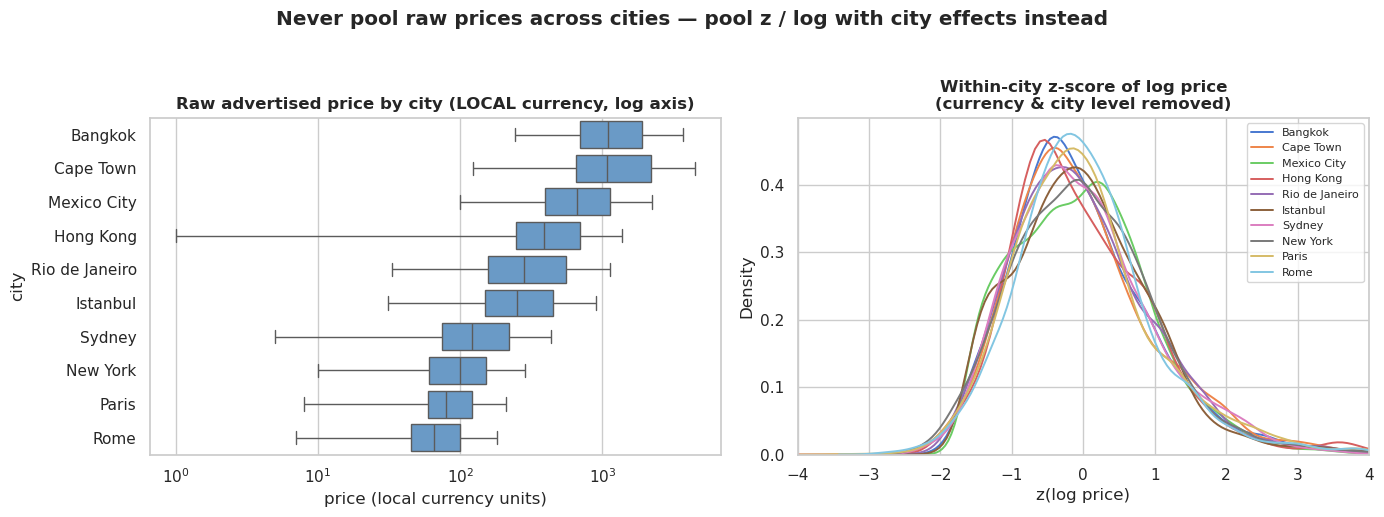

Per-city advertised price, LOCAL currency (do not compare levels across rows):
                    n  median  p25   p75
city                                    
Bangkok         19360    1100  700  1900
Cape Town       19086    1069  650  2200
Mexico City     20058     664  392  1124
Hong Kong        7087     386  248   700
Rio de Janeiro  26608     280  157   550
Istanbul        24517     252  150   449
Sydney          33630     120   74   219
New York        36984      99   60   151
Paris           64628      80   59   120
Rome            27641      65   45    99


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

eda = df_raw[(df_raw['price'] > 0) & (df_raw['accommodates'] > 0)].copy()
eda['log_price'] = np.log1p(eda['price'])
grp = eda.groupby('city')['log_price']
eda['z_price'] = (eda['log_price'] - grp.transform('mean')) / grp.transform('std')

city_order = eda.groupby('city')['price'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=eda, x='price', y='city', order=city_order,
            showfliers=False, color='#5B9BD5', ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Raw advertised price by city (LOCAL currency, log axis)', fontweight='bold')
axes[0].set_xlabel('price (local currency units)')

rng = np.random.RandomState(RANDOM_STATE)
for c in city_order:
    sub = eda.loc[eda.city == c, 'z_price']
    sns.kdeplot(sub.sample(min(3000, len(sub)), random_state=rng), ax=axes[1], label=c, lw=1.4)
axes[1].set_title('Within-city z-score of log price\n(currency & city level removed)', fontweight='bold')
axes[1].set_xlabel('z(log price)'); axes[1].set_xlim(-4, 4); axes[1].legend(fontsize=8)
plt.suptitle('Never pool raw prices across cities — pool z / log with city effects instead',
             fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

tbl = eda.groupby('city')['price'].agg(n='size', median='median',
                                       p25=lambda s: s.quantile(.25),
                                       p75=lambda s: s.quantile(.75)).loc[city_order]
print('Per-city advertised price, LOCAL currency (do not compare levels across rows):')
print(tbl.round(0).astype(int).to_string())

### 3.2 Missingness structure — the case for flags + imputation

Missingness here is **not random noise; it is information about the listing's history**:

- The **seven review-score columns are missing together** (pairwise missingness correlation ≈1): a listing either has review history or it doesn't. "Missing" mostly means **new or rarely-booked listing**, which is itself price-relevant — so we encode one `has_review_scores` flag and impute the scores (Step 6.2). Dropping ≈33% of rows would both waste data and *systematically delete the newest listings*, biasing the model toward established inventory.
- **Response/acceptance rates (≈46%/40% missing)** are self-reported-behaviour aggregates that only exist once a host has enquiry history. Same treatment: flag + impute. `host_response_time` is categorical, so its missingness becomes an explicit `no history` level rather than a fake imputed speed.
- **`district` is ≈87% missing** (only some cities publish districts) — above our 80% sparsity threshold it carries almost no usable signal and is dropped by the documented policy (Step 4.4), *not* ad hoc.
- **`bedrooms` (≈10% missing)** is structural too — mostly studios/rooms where the field was left blank; Step 5.4 imputes it with a deterministic occupancy heuristic plus a flag.

A tiny block of 165 rows is missing *all* host-profile fields (a failed host-record join); they get a single `host_info_missing` flag rather than five separate ones.

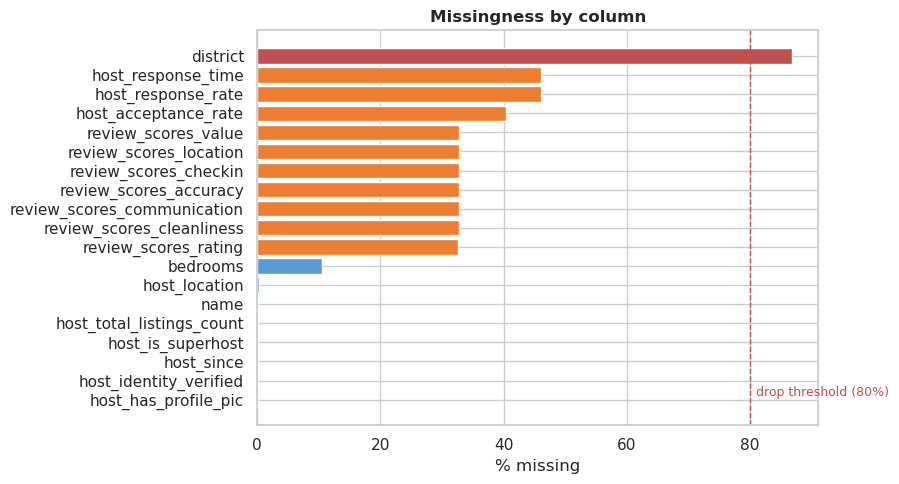

Review block co-missingness: min pairwise corr = 0.996 -> one shared has_review_scores flag suffices
Rows missing the ENTIRE host-profile block: 165 -> single host_info_missing flag


In [8]:
miss = df_raw.isna().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C0504D' if v > 80 else '#ED7D31' if v > 25 else '#5B9BD5' for v in miss.values]
ax.barh(miss.index[::-1], miss.values[::-1], color=colors[::-1])
ax.set_xlabel('% missing'); ax.set_title('Missingness by column', fontweight='bold')
ax.axvline(SPARSITY_THRESHOLD*100, color='#C0504D', ls='--', lw=1)
ax.text(SPARSITY_THRESHOLD*100+1, 0.2, f'drop threshold ({SPARSITY_THRESHOLD:.0%})',
        color='#C0504D', fontsize=9)
plt.tight_layout(); plt.show()

rev_cols = [c for c in df_raw.columns if c.startswith('review_scores')]
co = df_raw[rev_cols].isna().astype(int).corr()
print(f'Review block co-missingness: min pairwise corr = {co.values[np.triu_indices(7,1)].min():.3f} '
      '-> one shared has_review_scores flag suffices')
host_block = ['host_since','host_is_superhost','host_has_profile_pic',
              'host_identity_verified','host_total_listings_count']
all_missing = df_raw[host_block].isna().all(axis=1).sum()
print(f'Rows missing the ENTIRE host-profile block: {all_missing} -> single host_info_missing flag')

### 3.3 What drives price within a city?

Using the currency-free `z(log price)`, the classic pricing drivers rank as follows on this snapshot (within-city correlations): **capacity dominates** (`accommodates` ≈ +0.50, `bedrooms` ≈ +0.39), **room type** is next (entire place ≈ +0.35), then **amenity richness** (count ≈ +0.15). Two non-obvious readings:

- The capacity–price relationship is close to **linear in log price** up to ~8 guests — i.e. each extra guest multiplies the advertised rate by a roughly constant factor. That is exactly the pattern a log target captures with a plain linear term, and it motivates `persons_per_bedroom` (Step 5.4) as a *density* correction: at equal capacity, cramming more guests per bedroom prices lower.
- **Amenity count is a proxy for effort/service level**, not a causal lever — hosts who list 40 amenities also photograph, describe and manage better. We use it (plus specific amenity flags, Step 5.2) as a *signal*, and we will read its coefficients as association only.

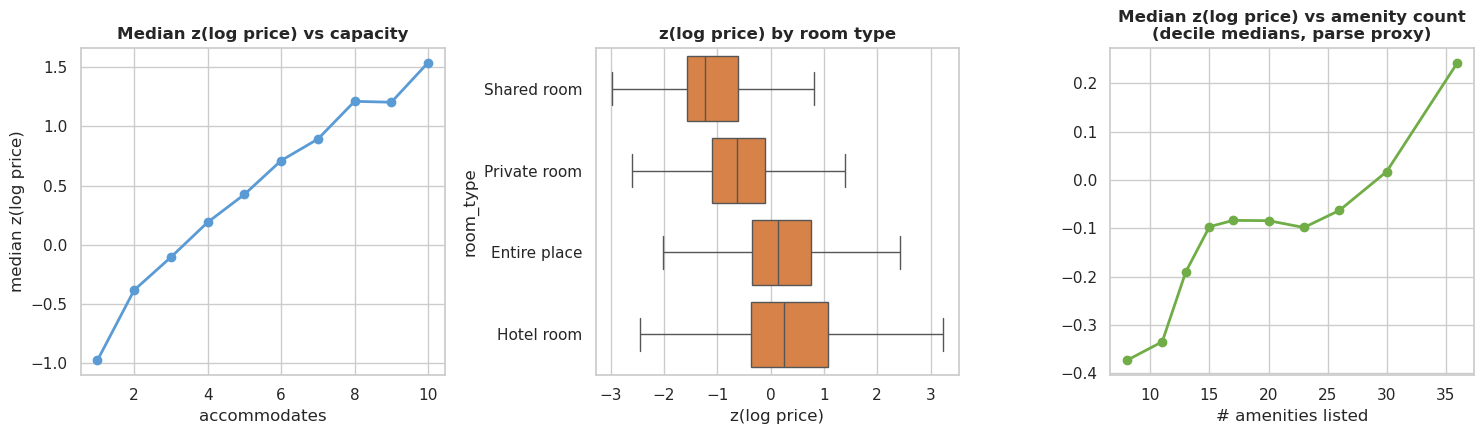

Within-city correlation with z(log price):
  accommodates             +0.503
  bedrooms                 +0.388
  entire place (0/1)       +0.348
  amenity count            +0.153
  superhost (0/1)          +0.015
  instant_bookable (0/1)   +0.000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cap = eda[eda['accommodates'] <= 10].groupby('accommodates')['z_price'].median()
axes[0].plot(cap.index, cap.values, marker='o', color='#5B9BD5', lw=2)
axes[0].set_title('Median z(log price) vs capacity', fontweight='bold')
axes[0].set_xlabel('accommodates'); axes[0].set_ylabel('median z(log price)')

order_rt = eda.groupby('room_type')['z_price'].median().sort_values().index
sns.boxplot(data=eda, x='z_price', y='room_type', order=order_rt,
            showfliers=False, color='#ED7D31', ax=axes[1])
axes[1].set_title('z(log price) by room type', fontweight='bold'); axes[1].set_xlabel('z(log price)')

# cheap amenity-count proxy before formal parsing in Step 5.2
eda['amenity_count_proxy'] = np.where(eda['amenities'] == '[]', 0,
                                      eda['amenities'].str.count('",') + 1)
dec = pd.qcut(eda['amenity_count_proxy'], 10, duplicates='drop')
am = eda.groupby(dec, observed=True).agg(x=('amenity_count_proxy','median'),
                                         y=('z_price','median'))
axes[2].plot(am['x'], am['y'], marker='o', color='#70AD47', lw=2)
axes[2].set_title('Median z(log price) vs amenity count\n(decile medians, parse proxy)', fontweight='bold')
axes[2].set_xlabel('# amenities listed')
plt.tight_layout(); plt.show()

drivers = {
    'accommodates': eda['z_price'].corr(eda['accommodates']),
    'bedrooms': eda['z_price'].corr(eda['bedrooms']),
    'entire place (0/1)': eda['z_price'].corr((eda['room_type'] == 'Entire place').astype(float)),
    'amenity count': eda['z_price'].corr(eda['amenity_count_proxy']),
    'superhost (0/1)': eda['z_price'].corr((eda['host_is_superhost'] == 't').astype(float)),
    'instant_bookable (0/1)': eda['z_price'].corr((eda['instant_bookable'] == 't').astype(float)),
}
print('Within-city correlation with z(log price):')
for k, v in sorted(drivers.items(), key=lambda kv: -abs(kv[1])):
    print(f'  {k:24s} {v:+.3f}')

### 3.4 Price geography: monocentric vs polycentric cities *(non-obvious pattern)*

A single "distance to city centre" feature quietly assumes every city is **monocentric** — price decays as you leave one centre. The data says otherwise:

- **Monocentric markets** (Mexico City, Rome, New York, Paris, Bangkok): correlation between distance-to-centre and z(log price) is clearly **negative** — the classic urban land-price gradient.
- **Polycentric / amenity-coast markets** (Sydney, Rio de Janeiro, Hong Kong, Istanbul): the correlation is **near zero or positive**. In Sydney and Rio the premium sits on **beaches** far from the CBD reference point; in Hong Kong, high-value areas spread across the harbour; Istanbul splits across the Bosphorus.

**Design consequence (Step 5.1):** distance-to-centre is kept — it is a strong, interpretable, privacy-friendly feature where it works — but it must be **complemented by coarse location cells** (rounded lat/lon) and a neighbourhood-popularity encoding, so tree-based models can recover *polycentric* premiums that a single radial feature cannot express. This is also why we do **not** hand the model raw coordinates: Step 5.1 shows the coarsened versions retain the pricing signal at ~1 km resolution while enforcing geo-privacy.

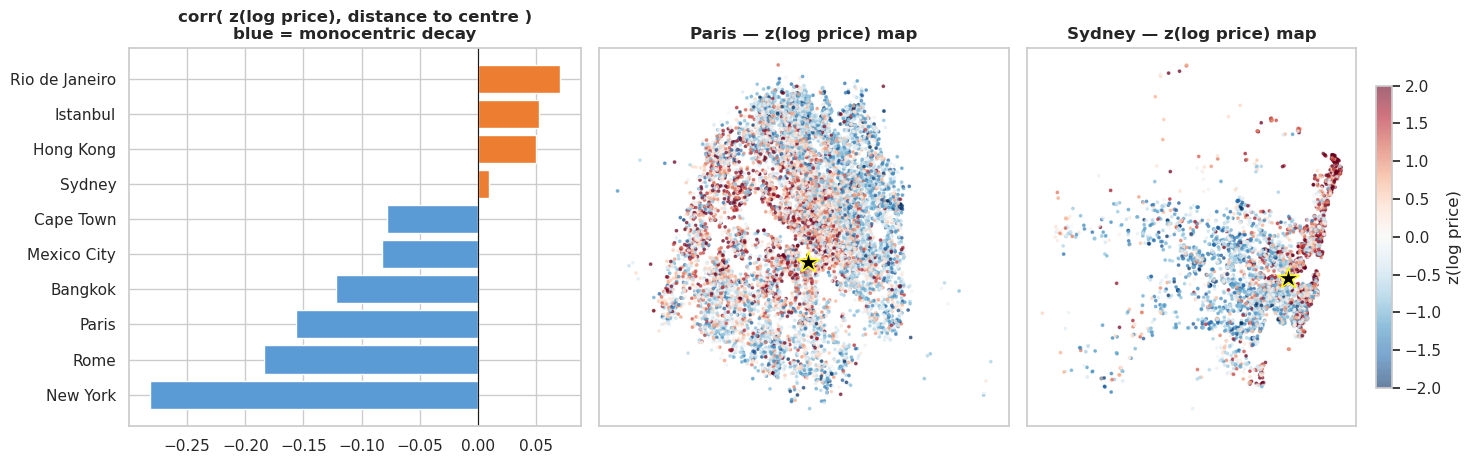

Paris: red core around the centre star = monocentric decay.
Sydney: premium follows the harbour/beaches, not radial distance -> polycentric.


In [10]:
R_EARTH_KM = 6371.0
def haversine_km(lat1, lon1, lat2, lon2):
    p = np.pi / 180.0
    a = (np.sin((lat2 - lat1) * p / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 2 * R_EARTH_KM * np.arcsin(np.sqrt(a))

clat = eda['city'].map({c: v[0] for c, v in CITY_CENTERS.items()})
clon = eda['city'].map({c: v[1] for c, v in CITY_CENTERS.items()})
eda['dist_center_km'] = haversine_km(eda['latitude'], eda['longitude'], clat, clon)

corrs = {}
for c, g in eda.groupby('city'):
    corrs[c] = g['z_price'].corr(g['dist_center_km'])
corrs = pd.Series(corrs).sort_values()

fig = plt.figure(figsize=(15, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1, 1])
ax0 = fig.add_subplot(gs[0])
ax0.barh(corrs.index, corrs.values,
         color=['#5B9BD5' if v < -0.05 else '#ED7D31' for v in corrs.values])
ax0.axvline(0, color='k', lw=0.8)
ax0.set_title('corr( z(log price), distance to centre )\nblue = monocentric decay', fontweight='bold')

for ax, city in [(fig.add_subplot(gs[1]), 'Paris'), (fig.add_subplot(gs[2]), 'Sydney')]:
    g = eda[eda.city == city].sample(12000, random_state=RANDOM_STATE)
    sc = ax.scatter(g['longitude'], g['latitude'], c=g['z_price'], cmap='RdBu_r',
                    vmin=-2, vmax=2, s=3, alpha=0.6)
    ax.plot(CITY_CENTERS[city][1], CITY_CENTERS[city][0], marker='*', ms=16,
            color='black', mec='yellow')
    ax.set_title(f'{city} — z(log price) map', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=ax, shrink=0.8, label='z(log price)')
plt.tight_layout(); plt.show()
print('Paris: red core around the centre star = monocentric decay.')
print('Sydney: premium follows the harbour/beaches, not radial distance -> polycentric.')

### 3.5 Pricing anomalies — evidence for the Step 4.4 outlier policy

Four distinct anomaly families show up, and they need **different** treatments (which is exactly why a documented policy beats ad-hoc deletion):

1. **Impossible values** — a small set of rows advertise `price = 0` (and a subset of those also report `accommodates = 0`). A nightly rate of zero is not a market price; these are extraction/data-entry errors → *Tier-1 validity removal, counted and logged*.
2. **Sentinel values** — `maximum_nights` contains `2147483647` (the 32-bit integer maximum — an unmistakable software sentinel, not a stay length) and other values above the platform ceiling of 1125 → *Tier-2 cap at 1125*. Same logic caps `minimum_nights` at 365.
3. **A structural regime, not an anomaly** — **67% of New York listings require ≥28-night minimum stays** (vs 2–13% elsewhere, second panel). This is New York's short-term-rental regulation pushing hosts into 30-day monthly rentals. And wherever monthly-minimum listings are the *minority* segment, they advertise markedly **lower nightly rates** (right panel: ≈0.6 SD lower in Hong Kong, ≈0.5 in Rome) — yet in New York, where ≥28 nights is the default regime, the gap vanishes. Deleting or capping these would erase a real market segment; instead Step 5.6 encodes `is_monthly_min` so models can *learn* the regime, including its city-dependent effect.
4. **Extreme-but-plausible luxury tails** — genuine villas/penthouses stretch each city's p99.9 far beyond p99. These are real listings, so rows are **kept**; the *target* is winsorised per-city at p99.5 (fit on train, Step 6.5) purely to stop a handful of prices dominating squared-error training, and the raw price is retained alongside for evaluation.

price <= 0                 : 113 rows
accommodates <= 0          : 85 rows (85 overlap with zero price)
maximum_nights == 2^31-1   : 3 rows (int32 sentinel)
maximum_nights > 1125      : 123 rows -> capped in Step 4.4
minimum_nights > 365       : 96 rows -> capped in Step 4.4


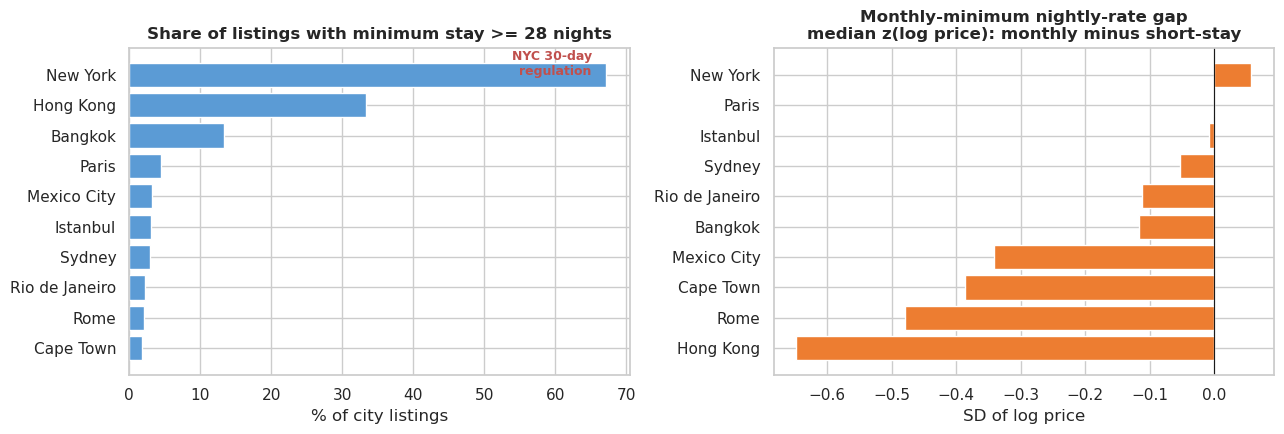

Luxury tail per city (kept; target winsorised at train p99.5 in Step 6.5):
                p99 (local)  p99.9 (local)
city                                      
Bangkok               15553          88641
Cape Town             22019          95653
Hong Kong              8799          19998
Istanbul               3806          33690
Mexico City            7295          39001
New York                850           3205
Paris                   600           2000
Rio de Janeiro         5697          53825
Rome                    600           7000
Sydney                 1721           5000


In [11]:
n_zero_price = int((df_raw['price'] <= 0).sum())
n_zero_cap   = int((df_raw['accommodates'] <= 0).sum())
n_overlap    = int(((df_raw['price'] <= 0) & (df_raw['accommodates'] <= 0)).sum())
n_sentinel   = int((df_raw['maximum_nights'] == 2147483647).sum())
n_over_cap   = int((df_raw['maximum_nights'] > MAX_NIGHTS_CAP).sum())
print(f'price <= 0                 : {n_zero_price} rows')
print(f'accommodates <= 0          : {n_zero_cap} rows ({n_overlap} overlap with zero price)')
print(f'maximum_nights == 2^31-1   : {n_sentinel} rows (int32 sentinel)')
print(f'maximum_nights > {MAX_NIGHTS_CAP}      : {n_over_cap} rows -> capped in Step 4.4')
print(f'minimum_nights > 365       : {int((df_raw["minimum_nights"]>365).sum())} rows -> capped in Step 4.4')

eda['is_monthly_min'] = eda['minimum_nights'] >= 28
share = eda.groupby('city')['is_monthly_min'].mean().mul(100).sort_values(ascending=False)
gap = (eda.groupby(['city', 'is_monthly_min'])['z_price'].median().unstack())
gap = (gap[True] - gap[False]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(share.index[::-1], share.values[::-1], color='#5B9BD5')
axes[0].set_title('Share of listings with minimum stay >= 28 nights', fontweight='bold')
axes[0].set_xlabel('% of city listings')
axes[0].annotate('NYC 30-day\nregulation', xy=(share.iloc[0]-2, 9), ha='right',
                 fontsize=9, fontweight='bold', color='#C0504D')
axes[1].barh(gap.index, gap.values, color='#ED7D31')
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_title('Monthly-minimum nightly-rate gap\nmedian z(log price): monthly minus short-stay',
                  fontweight='bold')
axes[1].set_xlabel('SD of log price')
plt.tight_layout(); plt.show()

p999 = eda.groupby('city')['price'].quantile([0.99, 0.999]).unstack().round(0).astype(int)
p999.columns = ['p99 (local)', 'p99.9 (local)']
print('Luxury tail per city (kept; target winsorised at train p99.5 in Step 6.5):')
print(p999.to_string())

### 3.6 Review and trust signals — what they measure *(governance-critical)*

Three EDA facts that reshape how review features may be used:

1. **Ratings are J-shaped and saturated**: the median overall score is **96/100** and three quarters of reviewed listings score ≥91. This is the well-documented platform-economy inflation pattern — bilateral reviewing, host retaliation risk and survivorship pressure compress scores against the ceiling. A "94" is therefore *not* strong evidence of a better stay than a "91": most of the scale's nominal range is unused.
2. **Superhost status carries almost no within-city price signal** (corr ≈ +0.02) — a useful negative result: platform-conferred badges are weak predictors of the advertised rate here, so we keep them cheap (single binary flags) rather than building elaborate trust features.
3. **Reviewed listings are slightly *cheaper*** than never-reviewed ones (negative `has_reviews` correlation). Plausible mechanisms: cheaper listings turn over more guests and accumulate reviews faster, and new premium inventory hasn't been reviewed yet. Either way, review presence partly encodes *turnover and listing age* — not quality.

**Governance stance (carried into Step 5.3 and Step 8):** review scores enter the model as **"guest-reported perception, as recorded by the platform"**, never as objective quality. Beyond inflation, published audit research on platform economies has repeatedly found guest ratings and demand can vary with **host demographics** (perceived race/gender) — meaning review features can quietly import societal bias. We keep the features (they carry some signal), but: they are flagged for imputation transparency, their effect sizes will be reported explicitly in Notebook 04's model cards, and any *decision* use (e.g. delisting advice) is out of scope.

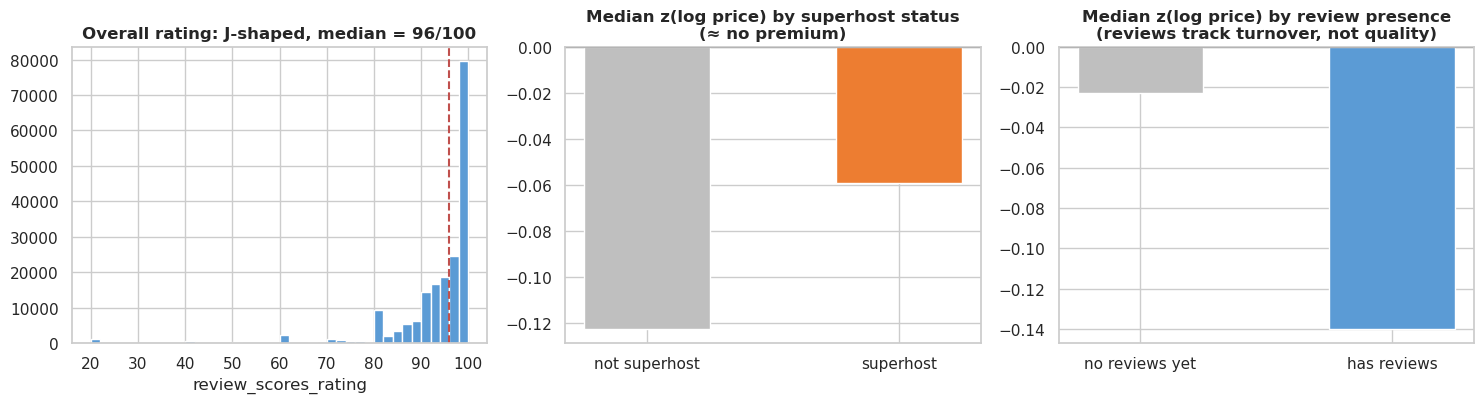

share of reviewed listings scoring >= 90/100: 81.7%
corr(z_price, superhost)   : +0.015
corr(z_price, has_reviews) : -0.086


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(eda['review_scores_rating'].dropna(), bins=40, color='#5B9BD5', edgecolor='white')
axes[0].axvline(eda['review_scores_rating'].median(), color='#C0504D', ls='--')
axes[0].set_title(f'Overall rating: J-shaped, median = '
                  f'{eda["review_scores_rating"].median():.0f}/100', fontweight='bold')
axes[0].set_xlabel('review_scores_rating')

sh = eda.groupby(eda['host_is_superhost'].eq('t'))['z_price'].median()
axes[1].bar(['not superhost', 'superhost'], sh.values, color=['#BFBFBF', '#ED7D31'], width=0.5)
axes[1].set_title('Median z(log price) by superhost status\n(≈ no premium)', fontweight='bold')
axes[1].axhline(0, color='k', lw=0.8)

hr = eda.groupby(eda['review_scores_rating'].notna())['z_price'].median()
axes[2].bar(['no reviews yet', 'has reviews'], hr.values, color=['#BFBFBF', '#5B9BD5'], width=0.5)
axes[2].set_title('Median z(log price) by review presence\n(reviews track turnover, not quality)',
                  fontweight='bold')
axes[2].axhline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

print(f"share of reviewed listings scoring >= 90/100: "
      f"{(eda['review_scores_rating'] >= 90).sum() / eda['review_scores_rating'].notna().sum() * 100:.1f}%")
print(f"corr(z_price, superhost)   : {eda['z_price'].corr(eda['host_is_superhost'].eq('t').astype(float)):+.3f}")
print(f"corr(z_price, has_reviews) : {eda['z_price'].corr(eda['review_scores_rating'].notna().astype(float)):+.3f}")
del eda  # free memory; cleaning restarts from df_raw with an auditable trail

## 4. Data Cleaning & Governance

Cleaning is executed as an **auditable sequence** — every step logs rows in/out and its justification into `audit_log`, which is printed as a table at the end of the section. Order matters and is deliberate:

1. **4.1 Type normalisation** first (dates parsed, `t/f` → 0/1) so later rules operate on typed data.
2. **4.2 Duplicate removal** *before* the privacy drop — the near-duplicate key needs `name` and `host_id`, so those columns are used transiently for quality control and *then* destroyed.
3. **4.3 Privacy & data minimisation** — PII and quasi-identifiers leave the table as early as the pipeline allows.
4. **4.4 The documented outlier policy** — validity rules and caps, applied from a written policy table rather than ad-hoc judgement.

In [13]:
df = df_raw.copy()
audit_log = []
def audit(step, before, after, note):
    audit_log.append({'step': step, 'rows_before': before, 'rows_after': after,
                      'rows_removed': before - after, 'note': note})

# --- 4.1 dtype normalisation ---------------------------------------------
n0 = len(df)
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
TF_COLS = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']
for c in TF_COLS:
    df[c] = df[c].map({'t': 1, 'f': 0})          # NaN preserved for flagging below

# 165 rows are missing the entire host-profile block (failed upstream join):
# one flag, then conservative zero-fill of the platform badges.
HOST_BLOCK = ['host_since', 'host_is_superhost', 'host_has_profile_pic',
              'host_identity_verified', 'host_total_listings_count']
df['host_info_missing'] = df[HOST_BLOCK].isna().all(axis=1).astype(int)
for c in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified']:
    df[c] = df[c].fillna(0).astype(int)
df['host_total_listings_count'] = df['host_total_listings_count'].fillna(0)
audit('4.1 dtype normalisation', n0, len(df),
      f"dates parsed; t/f -> 0/1; host_info_missing flag on {int(df['host_info_missing'].sum())} rows")
print(f"host_info_missing rows: {int(df['host_info_missing'].sum())}")
df[TF_COLS + ['host_info_missing']].sum().to_frame('count of 1s')

host_info_missing rows: 165


,count of 1s
host_is_superhost,50253
host_has_profile_pic,278631
host_identity_verified,201191
instant_bookable,115607
host_info_missing,165


### 4.2 Duplicate-listing removal

Three checks of increasing subtlety:

- **Primary-key duplicates** (`listing_id`) and **full-row duplicates** — both must be zero for a healthy extract, and are asserted.
- **Near-duplicates**: the same host advertising the "same" unit under multiple listing IDs — identical `host_id`, *exact* coordinates and identical `name`. These are typically re-posts or calendar-splitting artifacts; keeping them would let one physical property vote multiple times in training *and* risk leaking near-identical rows across the train/test boundary. We keep the first occurrence and log the removal. (This is the one step that legitimately *needs* `name` and `host_id` — the privacy drop follows immediately after.)

In [14]:
# --- 4.2 duplicates --------------------------------------------------------
assert df['listing_id'].duplicated().sum() == 0, 'primary key violated'
assert df.duplicated().sum() == 0, 'full-row duplicates present'
print('Primary-key and full-row duplicate checks: PASS (0 found)')

n0 = len(df)
near_dup = (df.duplicated(subset=['host_id', 'latitude', 'longitude', 'name'], keep='first')
            & df['name'].notna())
df = df[~near_dup].copy()
audit('4.2 near-duplicate removal', n0, len(df),
      'same host_id + exact coords + identical name -> kept first occurrence')
print(f'Near-duplicate listings removed: {n0 - len(df)}')

Primary-key and full-row duplicate checks: PASS (0 found)


Near-duplicate listings removed: 356


### 4.3 Privacy & data minimisation *(governance)*

We apply the **data-minimisation principle**: the modelling table may only carry attributes that (a) plausibly drive the advertised rate and (b) cannot re-identify a person. Concretely:

| Field | Action | Rationale |
|---|---|---|
| `name` (listing title) | **Drop** | Free text routinely embeds host first names, phone digits, unit numbers; it served its one legitimate purpose (near-dup key) above |
| `host_location` | **Drop** | Self-reported home location of the *person*, not the listing — a quasi-identifier with no pricing role |
| `host_id` | **Drop after use** | Needed only for the duplicate key; the host's scale is already captured non-identifiably by `host_total_listings_count` |
| `listing_id` | **Keep as opaque join key only** | A platform-issued numeric surrogate; it is *excluded from the feature matrix* (Step 6.6) and exists solely so predictions can be joined back |
| `latitude` / `longitude` | **Coarsen then drop** (Step 5.1) | Exact GPS + amenities can identify a *home*. The platform already jitters public pins by ~150 m; we go further and keep only ~1.1 km-resolution features |

Two things we deliberately do **not** do: we do not keep any hashed version of names (hashes of low-entropy PII are reversible by dictionary attack), and we do not fetch any external data keyed on hosts.

In [15]:
# --- 4.3 privacy & data minimisation --------------------------------------
PII_DROP = ['name', 'host_location', 'host_id']
n0 = len(df)
df = df.drop(columns=PII_DROP)
audit('4.3 PII drop', n0, len(df), f'dropped {PII_DROP}; listing_id retained as opaque key only')
print(f'Dropped PII / quasi-identifiers: {PII_DROP}')
print('listing_id retained as an opaque join key — excluded from features in Step 6.6.')
print('Exact latitude/longitude are consumed and destroyed by Step 5.1 (spatial coarsening).')

Dropped PII / quasi-identifiers: ['name', 'host_location', 'host_id']
listing_id retained as an opaque join key — excluded from features in Step 6.6.
Exact latitude/longitude are consumed and destroyed by Step 5.1 (spatial coarsening).


### 4.4 The documented outlier policy

**Policy statement.** Rows are removed *only* for violating physical validity (Tier 1). Extreme-but-plausible values are **winsorised (capped), never deleted** (Tiers 2–3), so the model keeps every genuine market segment while no single record dominates squared-error training. Sparse columns are dropped by a fixed threshold. Every action is parameterised in Step 0 and logged.

| Tier | Scope | Rule | Action | Fitted on |
|---|---|---|---|---|
| 1 — Validity | `price` | `price <= 0` (advertised nightly rate must be positive) | remove row, log count | fixed rule |
| 1 — Validity | `accommodates` | `accommodates <= 0` (a listing must host ≥1 guest) | remove row, log count | fixed rule |
| 2 — Domain caps | `minimum_nights` | cap at **365** (beyond a year is not nightly rental) | winsorise | fixed constant |
| 2 — Domain caps | `maximum_nights` | cap at **1125** (platform ceiling; kills the int32 sentinel) | winsorise | fixed constant |
| 2 — Domain caps | `bedrooms` | cap at **16** (max party size; stabilises a handful of 20–50-bedroom outliers) | winsorise | fixed constant |
| 2 — Sparsity | any column | > 80% missing (`district` only) | drop column | fixed threshold |
| 3 — Statistical caps | `host_total_listings_count` | cap at **train p99** | winsorise | **train only (Step 6.5)** |
| 3 — Target | `price` | winsorise at **per-city train p99.5**; raw price retained side-by-side | winsorise target copy | **train only (Step 6.5)** |

Tier 3 is intentionally *deferred to after the split* — percentile caps are statistics, and fitting them on the full data would leak test-set information into training. Tier 1–2 rules are constants, so applying them now is leak-free.

In [16]:
# --- 4.4 Tier 1: validity removals -----------------------------------------
n0 = len(df)
df = df[df['price'] > 0]
audit('4.4 Tier-1 price validity', n0, len(df), 'price <= 0 is not an advertised rate')
n1 = len(df)
df = df[df['accommodates'] > 0]
audit('4.4 Tier-1 capacity validity', n1, len(df), 'accommodates <= 0 is not a rentable listing')

# --- 4.4 Tier 2: fixed domain caps (winsorise, never delete) ---------------
capped = {
    'minimum_nights': int((df['minimum_nights'] > MIN_NIGHTS_CAP).sum()),
    'maximum_nights': int((df['maximum_nights'] > MAX_NIGHTS_CAP).sum()),
    'bedrooms':       int((df['bedrooms'] > BEDROOMS_CAP).sum()),
}
df['minimum_nights'] = df['minimum_nights'].clip(upper=MIN_NIGHTS_CAP)
df['maximum_nights'] = df['maximum_nights'].clip(upper=MAX_NIGHTS_CAP)
df['bedrooms']       = df['bedrooms'].clip(upper=BEDROOMS_CAP)
audit('4.4 Tier-2 domain caps', len(df), len(df),
      'winsorised: ' + ', '.join(f'{k} ({v} rows)' for k, v in capped.items()))

# --- 4.4 sparsity rule ------------------------------------------------------
sparse_cols = [c for c in df.columns if df[c].isna().mean() > SPARSITY_THRESHOLD]
df = df.drop(columns=sparse_cols)
audit('4.4 sparsity drop', len(df), len(df),
      f'columns > {SPARSITY_THRESHOLD:.0%} missing dropped: {sparse_cols}')

print('Tier-3 statistical caps (host listing count p99, per-city price p99.5) are FIT ON TRAIN in Step 6.5.')
print()
audit_df = pd.DataFrame(audit_log)
print(f'Rows: {len(df_raw):,} raw -> {len(df):,} clean '
      f'({len(df_raw) - len(df):,} removed = {(len(df_raw)-len(df))/len(df_raw)*100:.2f}%)')
audit_df

Tier-3 statistical caps (host listing count p99, per-city price p99.5) are FIT ON TRAIN in Step 6.5.

Rows: 279,712 raw -> 279,243 clean (469 removed = 0.17%)


,step,rows_before,rows_after,rows_removed,note
0,4.1 dtype normalisation,279712,279712,0,dates parsed; t/f -> 0/1; host_info_missing fl...
1,4.2 near-duplicate removal,279712,279356,356,same host_id + exact coords + identical name -...
2,4.3 PII drop,279356,279356,0,"dropped ['name', 'host_location', 'host_id']; ..."
3,4.4 Tier-1 price validity,279356,279243,113,price <= 0 is not an advertised rate
4,4.4 Tier-1 capacity validity,279243,279243,0,accommodates <= 0 is not a rentable listing
5,4.4 Tier-2 domain caps,279243,279243,0,"winsorised: minimum_nights (96 rows), maximum_..."
6,4.4 sparsity drop,279243,279243,0,columns > 80% missing dropped: ['district']


## 5. Feature Engineering — deterministic transforms

This section contains only **deterministic, row-wise transforms** (fixed constants, fixed rules, external reference points). Anything that must be *estimated from data* — imputation medians, the amenity vocabulary, frequency encodings, percentile caps, the scaler — is deferred to Step 6 and fitted on the training split only. That separation is the leakage-discipline backbone of this notebook:

> **Rule of thumb:** if a transform would produce a different result on a different sample, it is a *statistic* and must be fitted on train. If it produces the same result on any sample, it may run before the split.

Each subsection states its **logical** (why it should predict price), **ethical** (privacy/bias posture) and **mathematical** (functional form) rationale, as required by the project brief.

### 5.1 Spatial features — coarsen, derive, destroy

**Logical rationale.** Location is the single most famous driver of accommodation prices, but Step 3.4 showed its *shape* differs by city: monocentric decay in Paris/Rome/Mexico City/New York, polycentric premiums (beaches, harbour) in Sydney/Rio/Hong Kong/Istanbul. We therefore build three complementary encodings: `dist_center_km` (captures radial decay where it exists, from *fixed landmark constants*), coarse ~1.1 km grid coordinates `lat_coarse`/`lon_coarse` (lets tree models carve out polycentric premium pockets), and — in Step 6.4 — a train-fitted `neighbourhood_freq` popularity encoding for the 660 named neighbourhoods (one-hot at that cardinality would explode dimensionality and overfit).

**Ethical rationale (geo-privacy / data minimisation).** Exact GPS coordinates joined with amenities and capacity can re-identify a *private home*. Rounding to 2 decimal places quantises the world into cells of roughly **1.1 km × 0.5–1.1 km** (longitude cell width shrinks with latitude) — several city blocks — which is materially coarser than the ~150 m jitter the platform itself applies to public map pins. After the derived features are computed, the exact coordinates are **deleted from the table**, so no downstream artifact (S3 CSVs, models, logs) ever contains them. Coarsening rather than deleting location entirely preserves legitimate utility while honouring data minimisation. One caution carried to Step 8: *any* location feature — coarse cells, distance, neighbourhood — correlates with neighbourhood demographics and can act as a socio-economic proxy; coarsening reduces re-identification risk, not proxy risk.

**Mathematical rationale.** Distance uses the haversine great-circle formula, `d = 2R·asin(√(sin²(Δφ/2) + cosφ₁·cosφ₂·sin²(Δλ/2)))` with R = 6371 km — accurate to <0.5% at city scale, unlike naive Euclidean degrees, which are anisotropic (1° of longitude is 111 km at the equator but ~85 km in Paris and ~57 km in Hong Kong… in opposite hemispheres the error compounds). Rounding is a many-to-one quantiser: it destroys within-cell information *by design*, bounding location precision at the privacy budget we chose.

In [17]:
# --- 5.1 spatial: derive from exact coords, then destroy them ---------------
clat = df['city'].map({c: v[0] for c, v in CITY_CENTERS.items()})
clon = df['city'].map({c: v[1] for c, v in CITY_CENTERS.items()})
df['dist_center_km'] = haversine_km(df['latitude'], df['longitude'], clat, clon).round(3)

df['lat_coarse'] = df['latitude'].round(COORD_DECIMALS)
df['lon_coarse'] = df['longitude'].round(COORD_DECIMALS)

# demonstrate signal retention at coarse resolution before destroying exact coords
check = df[['city', 'price', 'lat_coarse', 'lon_coarse']].copy()
check['logp'] = np.log1p(check['price'])
g = check.groupby('city')['logp']
check['z'] = (check['logp'] - g.transform('mean')) / g.transform('std')
cell_med = check.groupby(['city', 'lat_coarse', 'lon_coarse'])['z'].transform('median')
print(f'corr( listing z(log price), its ~1.1km-cell median ) = {check["z"].corr(cell_med):.3f}'
      '  -> coarse cells retain strong location signal')

df = df.drop(columns=['latitude', 'longitude'])
print(f'Exact latitude/longitude DELETED. Kept: dist_center_km, '
      f'lat_coarse/lon_coarse ({COORD_DECIMALS} dp ~ 1.1 km cells).')
df[['city', 'dist_center_km', 'lat_coarse', 'lon_coarse']].head(3)

corr( listing z(log price), its ~1.1km-cell median ) = 0.437  -> coarse cells retain strong location signal
Exact latitude/longitude DELETED. Kept: dist_center_km, lat_coarse/lon_coarse (2 dp ~ 1.1 km cells).


,city,dist_center_km,lat_coarse,lon_coarse
0,Paris,3.934,48.89,2.33
1,Paris,3.705,48.89,2.35
2,Paris,3.940,48.88,2.32


### 5.2 Amenities — parsing a free-text field into governed features

**Logical rationale.** `amenities` is a JSON-like list of self-declared equipment/services. Step 3.3 showed amenity *count* correlates with price (+0.15 within city); individual amenities (pool, air conditioning, free parking) plausibly carry their own premiums. This is the richest untapped field in the file.

**Parsing & canonicalisation.** Values parse cleanly with `json.loads` (a fallback catches stragglers). Two normalisation problems remain: encoding artifacts (non-breaking spaces) and **vendor variants** — the platform emits qualified duplicates like `"Wifi – 1000 Mbps"`, `"Washer – In unit"`, `"Paid parking lot on premises – 10 spaces"`. We lowercase, strip the ` – qualifier` suffix (en/em dash or hyphen) so variants collapse onto their base amenity, and apply a tiny alias map (`fast wifi → wifi`, `hdtv → tv`). Without this, the same physical amenity would fragment into dozens of rare columns.

**Dimensionality policy (ethical + statistical).** Raw cardinality is ~800+ distinct strings — one-hot encoding all of them invites overfitting to idiosyncratic long-tail strings and bloats every downstream artifact. The committed policy: **binary flags for the top-`K=30` amenities by *training-set* frequency (Step 6.3), plus two governed aggregates** built here — `amenity_count` (total declared) and, in Step 6.3, `rare_amenity_count` (how many fall outside the vocabulary). Rare amenities are thus *grouped, not discarded*: a listing with a sauna, a piano and a telescope still gets credit for being unusually equipped, without the model memorising "telescope".

**Mathematical rationale.** Set-membership flags are the natural encoding for an unordered set-valued field; counts are its cardinality summary. Fixing the vocabulary on train makes the transform a *frozen function* at inference time — new/unseen amenity strings at prediction time simply route into `rare_amenity_count`, so the pipeline cannot crash on vocabulary drift.

*(Note the field is self-reported and unverified — an "amenity" is a claim, not an inspection. Fine for predicting the advertised rate, which is set by the same self-reporting host; not evidence of actual quality.)*

In [18]:
import ast
DASH_QUALIFIER = re.compile(r'\s+[\u2013\u2014-]\s+.*$')   # " – 1000 Mbps", " — In unit", " - 2 spaces"
ALIASES = {'fast wifi': 'wifi', 'free wifi': 'wifi', 'hdtv': 'tv',
           'washer in unit': 'washer', 'dryer in unit': 'dryer'}

def parse_amenities(raw):
    if not isinstance(raw, str) or raw.strip() in ('', '[]'):
        return []
    txt = raw.replace('\xa0', ' ')
    try:
        items = json.loads(txt)
    except Exception:
        try:
            items = ast.literal_eval(txt)
        except Exception:
            return []
    out = set()
    for it in items:
        a = str(it).replace('\xa0', ' ').strip().lower()
        a = DASH_QUALIFIER.sub('', a).strip()
        out.add(ALIASES.get(a, a))
    return sorted(out)

df['amen_list'] = df['amenities'].map(parse_amenities)
df['amenity_count'] = df['amen_list'].str.len()
df = df.drop(columns=['amenities'])

n_empty = int((df['amenity_count'] == 0).sum())
distinct = set()
for lst in df['amen_list']: distinct.update(lst)
print(f'Parsed OK. Distinct canonical amenities: {len(distinct):,} '
      f'(pre-canonicalisation the raw strings exceed 800)')
print(f'Listings declaring zero amenities: {n_empty}')
print(f'amenity_count: median={df.amenity_count.median():.0f}, p95={df.amenity_count.quantile(.95):.0f}')
print('Top-K flag vocabulary is fitted on TRAIN ONLY in Step 6.3.')

Parsed OK. Distinct canonical amenities: 2,729 (pre-canonicalisation the raw strings exceed 800)
Listings declaring zero amenities: 124
amenity_count: median=18, p95=36
Top-K flag vocabulary is fitted on TRAIN ONLY in Step 6.3.


### 5.3 Host features — track record without identity

**Logical rationale.** Hosts differ in professionalism, and professional operators price differently (often higher base rates, dynamic pricing). Non-identifying proxies available: **tenure** (`host_tenure_days` = snapshot − `host_since`; experience and listing-age proxy), **scale** (`host_total_listings_count`; separates home-sharers from property managers — heavy-tailed, so Step 6.5 caps at train-p99 and takes `log1p`), **platform badges** (`superhost`, `identity_verified`, `profile_pic` — Step 3.6 showed these are weak price signals, so they stay as cheap binaries), **responsiveness** (`host_response_time/rate`, `host_acceptance_rate`) and `instant_bookable`.

**Missingness-as-signal (ethical + statistical).** Response/acceptance metrics are missing for ≈46%/40% of rows — hosts with *no enquiry history yet*. That absence is informative (new/inactive host), i.e. the data are **MNAR**, so mean-filling without a trace would fabricate a track record and hide it from the model. The committed pattern — **explicit indicator flag + imputation** — is implemented in Step 6.2 with *train* medians; the categorical `host_response_time` gets an honest **`no history`** level instead of a fabricated speed. No rows are dropped for missingness anywhere in this pipeline.

**Mathematical rationale.** Tenure in days is a linear clock; badge fields are Bernoulli indicators; `log1p` on listing count linearises a multiplicative scale variable (1 → 2 listings is a bigger operational change than 101 → 102). The flag+impute pattern decomposes each incomplete variable into `(value_if_observed, was_observed)` — a lossless encoding that lets any downstream model estimate a separate intercept for the unobserved group instead of silently absorbing the imputation constant.

In [19]:
# --- 5.3 host features -------------------------------------------------------
df['host_tenure_days'] = (SNAPSHOT_DATE - df['host_since']).dt.days
df = df.drop(columns=['host_since'])

# missingness flags NOW (deterministic); imputation values fitted on train in Step 6.2
df['host_response_rate_missing']   = df['host_response_rate'].isna().astype(int)
df['host_acceptance_rate_missing'] = df['host_acceptance_rate'].isna().astype(int)

RESPONSE_TIME_LEVELS = ['within an hour', 'within a few hours', 'within a day',
                        'a few days or more', 'no history']
df['host_response_time'] = df['host_response_time'].fillna('no history')
assert set(df['host_response_time'].unique()) <= set(RESPONSE_TIME_LEVELS)

print(df[['host_tenure_days', 'host_total_listings_count']].describe().round(1).T.to_string())
print()
print('host_response_time levels (missing -> honest "no history" category):')
print(df['host_response_time'].value_counts().to_string())

                              count    mean    std  min     25%     50%     75%     max
host_tenure_days           279078.0  1785.6  889.5  3.0  1059.0  1843.0  2436.0  4584.0
host_total_listings_count  279243.0    24.2  283.0  0.0     1.0     1.0     4.0  7235.0

host_response_time levels (missing -> honest "no history" category):
host_response_time
no history            128643
within an hour         83196
within a few hours     28871
within a day           23398
a few days or more     15135


### 5.4 Capacity & size — deterministic imputation of `bedrooms`

**Logical rationale.** Step 3.3 ranked `accommodates` as the strongest single driver (within-city corr ≈ +0.50). `bedrooms` adds the *configuration*: at equal capacity, more bedrooms means more privacy and a higher advertised rate. Their ratio, **`persons_per_bedroom`**, is an occupancy-density feature — high values (4 guests / 1 bedroom) indicate sofa-bed/dorm-style economy listings; low values indicate spacious premium ones.

**Why a heuristic imputation here instead of a median in Step 6?** `bedrooms` is ≈10% missing, dominated by studios and single rooms where the field was left blank. A *global median* (data-fitted, would belong in Step 6) ignores what we already know about each listing; instead we use a **deterministic occupancy rule** — `ceil(accommodates / 2)`, floored at 1 — encoding the near-universal 2-guests-per-bedroom convention. Because the rule is a fixed function of the same row, it is sample-independent (leak-free before the split), it respects each listing's size, and — paired with the mandatory **`bedrooms_missing` flag** — the model can still discount imputed values. The flag preserves the MNAR trace exactly as the project's missing-data policy requires.

**Mathematical rationale.** `persons_per_bedroom = accommodates / max(bedrooms, 1)` is scale-free and bounded below by ~0.5 in practice; using the imputed denominator keeps it defined for every row. `ceil(a/2) ≥ 1` guarantees no division by zero and keeps the imputation on the integer lattice of real bedroom counts.

In [20]:
# --- 5.4 capacity & size -----------------------------------------------------
df['bedrooms_missing'] = df['bedrooms'].isna().astype(int)
df['bedrooms'] = df['bedrooms'].fillna(np.ceil(df['accommodates'] / 2).clip(lower=1))
df['persons_per_bedroom'] = (df['accommodates'] / df['bedrooms'].clip(lower=1)).round(3)

print(f"bedrooms imputed via ceil(accommodates/2) on {int(df['bedrooms_missing'].sum()):,} rows "
      f"({df['bedrooms_missing'].mean()*100:.1f}%) — flag retained")
df[['accommodates', 'bedrooms', 'bedrooms_missing', 'persons_per_bedroom']].describe().round(2).T

bedrooms imputed via ceil(accommodates/2) on 29,290 rows (10.5%) — flag retained


,count,mean,std,min,25%,50%,75%,max
accommodates,279243.0,3.29,2.13,1.00,2.0,2.0,4.0,16.0
bedrooms,279243.0,1.48,0.96,1.00,1.0,1.0,2.0,16.0
bedrooms_missing,279243.0,0.10,0.31,0.00,0.0,0.0,0.0,1.0
persons_per_bedroom,279243.0,2.30,1.03,0.06,2.0,2.0,2.5,16.0


### 5.5 Property-type grouping — 144 strings → 7 semantic buckets

**Logical rationale.** `property_type` has **144 distinct values** with a brutal long tail ("Entire apartment" ≈ 139k rows; dozens of types with <50 rows). One-hot encoding all of them would add ~140 mostly-empty columns whose coefficients are pure noise. But the field carries real signal orthogonal to `room_type` (which already encodes the entire/private/shared/hotel axis): the *dwelling kind* — apartment vs standalone house vs B&B vs hotel-operated vs "unique stay" (boats, treehouses, riads…), the last of which commands novelty premiums.

**Why rule-based buckets instead of frequency buckets?** A top-N-by-frequency grouping is a *statistic* — the buckets would shift on every retrain and any train/test frequency difference leaks. **Keyword rules are deterministic, human-auditable, and stable across retrains**: "does the string contain *hotel/hostel*? → `hotel_hostel`", etc., with precedence ordering (hotel before apartment so "Room in aparthotel" lands correctly). The residual `other` bucket absorbs the unclassifiable tail. Deterministic ⇒ safely applied pre-split; auditable ⇒ a reviewer can read the seven rules in one screen — which is exactly the governance posture we want for a feature that shapes price predictions.

In [21]:
# --- 5.5 property grouping ---------------------------------------------------
def property_group(pt):
    t = str(pt).lower()
    if any(k in t for k in ('hotel', 'hostel', 'resort')):                 return 'hotel_hostel'
    if any(k in t for k in ('bed and breakfast', 'guesthouse', 'guest suite')): return 'bnb_guesthouse'
    if any(k in t for k in ('boat', 'camper', 'tent', 'castle', 'treehouse', 'yurt',
                            'tiny house', 'island', 'cave', 'dome', 'windmill', 'lighthouse',
                            'barn', 'farm stay', 'earth house', 'hut', 'tipi', 'igloo',
                            'ryokan', 'riad', 'casa particular', 'minsu', 'pension',
                            'cycladic', 'dammuso', 'trullo', 'shepherd')): return 'unique_stay'
    if any(k in t for k in ('apartment', 'condominium', 'loft', 'serviced')): return 'apartment_condo'
    if any(k in t for k in ('house', 'townhouse', 'villa', 'cottage', 'bungalow',
                            'cabin', 'chalet')):                            return 'house_villa'
    if 'private room' in t or 'shared room' in t or 'room in' in t:         return 'room_other_dwelling'
    return 'other'

df['property_group'] = df['property_type'].map(property_group)
PROPERTY_GROUP_LEVELS = sorted(df['property_group'].unique())
xtab = df.groupby('property_group').agg(n=('property_group', 'size'),
                                        n_raw_types=('property_type', 'nunique'))
print(f"{df['property_type'].nunique()} raw property_type values -> "
      f"{len(PROPERTY_GROUP_LEVELS)} governed buckets:")
print(xtab.sort_values('n', ascending=False).to_string())
df = df.drop(columns=['property_type'])

144 raw property_type values -> 7 governed buckets:
                          n  n_raw_types
property_group                          
apartment_condo      216474           14
house_villa           35916           21
hotel_hostel          12980           14
bnb_guesthouse        11678           11
unique_stay            1254           57
room_other_dwelling     596           17
other                   345           10


### 5.6 Stay-length terms — encoding the monthly-rental regime

**Logical rationale.** Step 3.5 exposed a genuine market structure: **67% of New York listings carry ≥28-night minimums** (the 30-day regulation), and monthly-minimum listings advertise markedly lower *nightly* rates wherever they are the minority segment (≈0.6 SD lower in Hong Kong, ≈0.5 in Rome) — while in New York, where monthly terms are the default, the within-city gap disappears. That city-dependent pattern is exactly what an explicit `is_monthly_min` indicator lets flexible models capture (as a city × regime interaction); without it, pooled models would blur two genuinely different rental products into one estimate. `is_monthly_min = (minimum_nights ≥ 28)` gives the regime a dedicated, interpretable switch; `log1p(minimum_nights)` keeps the residual within-regime gradient (2-night vs 7-night minimums also differ) on a sane scale after the Tier-2 cap. `maximum_nights` (capped at 1125) weakly separates "short-stay only" listings from open-ended ones. `instant_bookable` was mapped to 0/1 in Step 4.1.

**Mathematical rationale.** The threshold-at-28 indicator plus log level is a standard *broken-stick* encoding: the indicator captures the discrete regime shift a smooth transform cannot, while the log compresses the 1→365 range so the cap does not create a leverage point. (28 is the platform's own monthly-stay boundary, i.e. a domain constant — not a fitted knot.)

In [22]:
# --- 5.6 stay-length terms ----------------------------------------------------
df['is_monthly_min'] = (df['minimum_nights'] >= 28).astype(int)
df['log_minimum_nights'] = np.log1p(df['minimum_nights'])
print(f"is_monthly_min = 1 on {df['is_monthly_min'].mean()*100:.1f}% of listings "
      f"(New York alone: {df.loc[df.city=='New York','is_monthly_min'].mean()*100:.1f}%)")
print()
print('Columns now in the working table:')
print(sorted(df.columns.tolist()))

is_monthly_min = 1 on 13.1% of listings (New York alone: 67.1%)

Columns now in the working table:
['accommodates', 'amen_list', 'amenity_count', 'bedrooms', 'bedrooms_missing', 'city', 'dist_center_km', 'host_acceptance_rate', 'host_acceptance_rate_missing', 'host_has_profile_pic', 'host_identity_verified', 'host_info_missing', 'host_is_superhost', 'host_response_rate', 'host_response_rate_missing', 'host_response_time', 'host_tenure_days', 'host_total_listings_count', 'instant_bookable', 'is_monthly_min', 'lat_coarse', 'listing_id', 'log_minimum_nights', 'lon_coarse', 'maximum_nights', 'minimum_nights', 'neighbourhood', 'persons_per_bedroom', 'price', 'property_group', 'review_scores_accuracy', 'review_scores_checkin', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_rating', 'review_scores_value', 'room_type']


## 6. Train/Test Split, then Train-Fitted Transforms

**Why the split happens *now*, mid-preprocessing.** Everything in Step 4–Step 5 was a fixed rule; everything from here on is an *estimated statistic* (medians, vocabularies, frequencies, percentiles, scaler moments). Fitting statistics on the full dataset would let the test set influence the training representation — a quiet form of leakage that inflates offline metrics. So we split first and fit every remaining transform on **train only**, exactly as a production inference service would: at prediction time only frozen artifacts are available (they are exported to JSON in Step 7).

**Why stratify by `city` rather than plain random?** The target's *level* differs by city (currency + market), and city is our currency-normalisation device (Step 6.5). Stratifying on city guarantees both splits contain every market in identical proportion — so per-city caps, encodings and (in Notebook 02+) per-city error reporting are all well-defined on both sides. For a continuous target, stratifying on a key covariate is the standard analogue of the class-stratification used in the reference classification notebook.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

train_df, test_df = train_test_split(df, test_size=TEST_SIZE,
                                     random_state=RANDOM_STATE, stratify=df['city'])
train_df, test_df = train_df.copy(), test_df.copy()
print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows')
parity = pd.concat([train_df['city'].value_counts(normalize=True).rename('train %'),
                    test_df['city'].value_counts(normalize=True).rename('test %')], axis=1) * 100
print('City mix parity (stratification check):')
print(parity.round(2).to_string())

Train: 223,394 rows | Test: 55,849 rows
City mix parity (stratification check):
                train %  test %
city                           
Paris             23.13   23.13
New York          13.21   13.21
Sydney            12.04   12.04
Rome               9.88    9.88
Rio de Janeiro     9.53    9.53
Istanbul           8.76    8.76
Mexico City        7.17    7.17
Bangkok            6.92    6.92
Cape Town          6.83    6.83
Hong Kong          2.53    2.53


### 6.2 Missing-value imputation — flags first, train medians second

The flags were created deterministically in Step 4–Step 5 (`host_response_rate_missing`, `host_acceptance_rate_missing`, `bedrooms_missing`, `host_info_missing`); here we add the one review-block flag (`has_review_scores` — Step 3.2 showed the seven scores are missing *together*) and then impute every remaining numeric gap with the **training-set median**. Median over mean because every one of these columns is bounded and skewed (ratings pile at 100, rates at 1.0), where the mean is a poor centre. The imputation values are recorded in the artifacts JSON so that scoring code applies *identical* constants — never re-estimates them on incoming data. **No rows are dropped for missingness.**

In [24]:
REVIEW_COLS = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
               'review_scores_checkin', 'review_scores_communication',
               'review_scores_location', 'review_scores_value']
for part in (train_df, test_df):
    part['has_review_scores'] = part['review_scores_rating'].notna().astype(int)

IMPUTE_COLS = REVIEW_COLS + ['host_response_rate', 'host_acceptance_rate', 'host_tenure_days']
IMPUTATION_VALUES = {c: float(train_df[c].median()) for c in IMPUTE_COLS}
for part in (train_df, test_df):
    for c, v in IMPUTATION_VALUES.items():
        part[c] = part[c].fillna(v)

print(f"has_review_scores = 0 on {100 - train_df['has_review_scores'].mean()*100:.1f}% of train rows")
print('Train-fitted imputation constants (frozen into artifacts JSON):')
for c, v in IMPUTATION_VALUES.items():
    print(f'  {c:32s} -> {v:g}')

has_review_scores = 0 on 32.6% of train rows
Train-fitted imputation constants (frozen into artifacts JSON):
  review_scores_rating             -> 96
  review_scores_accuracy           -> 10
  review_scores_cleanliness        -> 10
  review_scores_checkin            -> 10
  review_scores_communication      -> 10
  review_scores_location           -> 10
  review_scores_value              -> 10
  host_response_rate               -> 1
  host_acceptance_rate             -> 0.98
  host_tenure_days                 -> 1842


### 6.3 Amenity vocabulary — top-K fit on train, rare amenities grouped

The Step 5.2 policy executes here: the **top-`K=30` canonical amenities by training frequency** become binary flags; everything outside the vocabulary is *grouped* into `rare_amenity_count` rather than discarded, so unusual equipment still contributes signal without per-string columns. Because the vocabulary is frozen from train, an amenity string never seen in training (vocabulary drift on fresh data) routes safely into the rare count at inference time.

In [25]:
vocab_counter = Counter()
for lst in train_df['amen_list']:
    vocab_counter.update(lst)
AMENITY_VOCAB = [a for a, _ in vocab_counter.most_common(TOP_K_AMENITIES)]
slug = lambda a: 'amen_' + re.sub(r'[^a-z0-9]+', '_', a).strip('_')
AMEN_FLAG_COLS = [slug(a) for a in AMENITY_VOCAB]

for part in (train_df, test_df):
    amen_sets = part['amen_list'].map(set)
    for a in AMENITY_VOCAB:
        part[slug(a)] = amen_sets.map(lambda s, a=a: int(a in s))
    in_vocab = amen_sets.map(lambda s: len(s & set(AMENITY_VOCAB)))
    part['rare_amenity_count'] = part['amenity_count'] - in_vocab
    part.drop(columns=['amen_list'], inplace=True)

print(f'Vocabulary (fit on train, K={TOP_K_AMENITIES}):')
for i, a in enumerate(AMENITY_VOCAB, 1):
    print(f'  {i:>2}. {a:32s} {vocab_counter[a]/len(train_df)*100:5.1f}% of train listings')
print(f"rare_amenity_count: median={train_df['rare_amenity_count'].median():.0f}, "
      f"p95={train_df['rare_amenity_count'].quantile(.95):.0f}")

Vocabulary (fit on train, K=30):
   1. wifi                              93.4% of train listings
   2. essentials                        90.7% of train listings
   3. kitchen                           86.2% of train listings
   4. long term stays allowed           86.2% of train listings
   5. tv                                76.3% of train listings
   6. hangers                           75.6% of train listings
   7. hair dryer                        67.4% of train listings
   8. iron                              67.1% of train listings
   9. washer                            66.8% of train listings
  10. heating                           66.0% of train listings
  11. dedicated workspace               64.1% of train listings
  12. shampoo                           62.3% of train listings
  13. hot water                         59.0% of train listings
  14. smoke alarm                       55.9% of train listings
  15. air conditioning                  51.0% of train listings
  16. d

### 6.4 Neighbourhood popularity encoding *(train-fitted)*

660 named neighbourhoods are far too many to one-hot and too identifying to leave as raw high-cardinality labels in every artifact. We encode each `(city, neighbourhood)` pair by its **share of that training split's listings** — a supply-density feature: dense short-term-rental neighbourhoods are the touristic/premium ones. Crucially this is *frequency* encoding, not *target* encoding: it never touches `price`, so it cannot leak the label the way target-mean encoding can. Pairs unseen in training map to 0 ("no known supply"), which is also the correct behaviour for genuinely new neighbourhoods at inference time.

In [26]:
for part in (train_df, test_df):
    part['nbhd_key'] = part['city'] + '||' + part['neighbourhood'].fillna('unknown')
NEIGHBOURHOOD_FREQ = train_df['nbhd_key'].value_counts(normalize=True).to_dict()
for part in (train_df, test_df):
    part['neighbourhood_freq'] = part['nbhd_key'].map(NEIGHBOURHOOD_FREQ).fillna(0.0)
    part.drop(columns=['nbhd_key', 'neighbourhood'], inplace=True)

unseen = int((test_df['neighbourhood_freq'] == 0).sum())
print(f'{len(NEIGHBOURHOOD_FREQ)} (city, neighbourhood) pairs encoded from train; '
      f'{unseen} test rows map to unseen pairs (-> 0.0)')

651 (city, neighbourhood) pairs encoded from train; 11 test rows map to unseen pairs (-> 0.0)


### 6.5 Target construction — the currency-normalisation identity, Tier-3 caps

**The mathematics that makes ten currencies poolable.** Let a listing's advertised rate in a common reference currency be `p*`, and the city's exchange rate to its local currency be `fx_c`. The recorded local price is `p = fx_c · p*`, so

&nbsp;&nbsp;&nbsp;&nbsp;`log(p) = log(fx_c) + log(p*)`

— on the log scale, **currency is an additive constant per city**. A pooled regression on `log1p(price)` that includes **city one-hot dummies** (Step 6.6) therefore absorbs the entire currency scale (and the city's overall price level) into the city intercepts, while every other coefficient learns *within-city, currency-free* structure. This is why the committed strategy is *"per-city normalisation via city effects on the log scale"* rather than converting currencies with external FX tables — the identity is exact, needs no external data, has no FX-date ambiguity, and matches the empirical log-normality shown in Step 3.1. The same argument is why later notebooks must report errors on the log scale (a multiplicative, currency-free "% error") or back-transform **within city** — never pooled raw currency units.

**Tier-3 of the outlier policy (train-fitted caps).** `host_total_listings_count` is capped at the train p99 then `log1p`-transformed. The target copy is winsorised at the **per-city train p99.5**: Step 3.5 established the luxury tail is real, so rows are kept, but a handful of six-figure villas would otherwise dominate a squared-error fit. The **raw price is retained side-by-side in the label files** — evaluation can (and should) report metrics on both, and nothing about the winsorisation is hidden: the caps ship in the artifacts JSON.

In [27]:
# --- Tier-3a: host listing count cap (train p99) -----------------------------
HOST_COUNT_CAP = float(train_df['host_total_listings_count'].quantile(COUNT_CAP_QUANTILE))
for part in (train_df, test_df):
    part['log_host_listings'] = np.log1p(part['host_total_listings_count'].clip(upper=HOST_COUNT_CAP))
    part.drop(columns=['host_total_listings_count'], inplace=True)

# --- Tier-3b: per-city target winsorisation (train p99.5) --------------------
PRICE_CAPS = train_df.groupby('city')['price'].quantile(PRICE_CAP_QUANTILE).to_dict()
for name, part in [('train', train_df), ('test', test_df)]:
    cap = part['city'].map(PRICE_CAPS)
    n_capped = int((part['price'] > cap).sum())          # diagnostic only — NOT a feature
    part['price_capped'] = np.minimum(part['price'], cap)
    part['log_price'] = np.log1p(part['price_capped'])
    print(f'{name}: {n_capped} rows ({n_capped/len(part)*100:.2f}%) above their city cap -> winsorised')

print(f'host_total_listings_count cap (train p{COUNT_CAP_QUANTILE:.0%}): {HOST_COUNT_CAP:.0f}')
print('Per-city price caps, LOCAL currency (train p99.5):')
print(pd.Series(PRICE_CAPS).round(0).astype(int).sort_values(ascending=False).to_string())

train: 1097 rows (0.49%) above their city cap -> winsorised
test: 275 rows (0.49%) above their city cap -> winsorised
host_total_listings_count cap (train p99%): 279
Per-city price caps, LOCAL currency (train p99.5):
Cape Town         31341
Bangkok           31106
Mexico City       11510
Hong Kong         10000
Rio de Janeiro    10000
Istanbul           6794
Sydney             2256
New York           1200
Rome                999
Paris               888


### 6.6 Categorical encoding & feature assembly

The four closed-set categoricals (`city`, `room_type`, `property_group`, `host_response_time`) are one-hot encoded with **category lists frozen from train** (exported to artifacts), so train/test — and any future scoring batch — produce byte-identical column sets; a category never seen in training encodes as all-zeros instead of crashing or spawning a new column. We keep all levels (no `drop_first`): the redundancy is harmless for the regularised/tree models planned in Notebook 02 and keeps every coefficient directly interpretable. Finally the feature matrix is assembled from an **explicit whitelist** — identifiers (`listing_id`) and anything derived from the target (`price`, `price_capped`, `log_price`) are structurally excluded, which is our last line of defence against target leakage.

In [28]:
ONEHOT_LEVELS = {
    'city':               sorted(train_df['city'].unique()),
    'room_type':          sorted(train_df['room_type'].unique()),
    'property_group':     PROPERTY_GROUP_LEVELS,
    'host_response_time': RESPONSE_TIME_LEVELS,
}
def encode_onehot(part):
    pieces = []
    for col, levels in ONEHOT_LEVELS.items():
        cat = pd.Categorical(part[col], categories=levels)
        d = pd.get_dummies(cat, prefix=col).astype(int)
        d.index = part.index
        pieces.append(d)
    out = pd.concat(pieces, axis=1)
    out.columns = [re.sub(r'\W+', '_', c).strip('_') for c in out.columns]
    return out

CONTINUOUS_FEATURES = (['accommodates', 'bedrooms', 'persons_per_bedroom', 'dist_center_km',
                        'lat_coarse', 'lon_coarse', 'amenity_count', 'rare_amenity_count',
                        'neighbourhood_freq', 'host_tenure_days', 'host_response_rate',
                        'host_acceptance_rate', 'log_host_listings', 'log_minimum_nights',
                        'maximum_nights'] + REVIEW_COLS)
BINARY_FEATURES = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
                   'instant_bookable', 'host_info_missing', 'host_response_rate_missing',
                   'host_acceptance_rate_missing', 'bedrooms_missing', 'has_review_scores',
                   'is_monthly_min']

X_train = pd.concat([train_df[CONTINUOUS_FEATURES + BINARY_FEATURES + AMEN_FLAG_COLS],
                     encode_onehot(train_df)], axis=1)
X_test  = pd.concat([test_df[CONTINUOUS_FEATURES + BINARY_FEATURES + AMEN_FLAG_COLS],
                     encode_onehot(test_df)], axis=1)
y_train = train_df[['log_price', 'price']].copy()   # log target + raw price for evaluation
y_test  = test_df[['log_price', 'price']].copy()

FEATURE_COLUMNS = X_train.columns.tolist()
onehot_n = len(FEATURE_COLUMNS) - len(CONTINUOUS_FEATURES) - len(BINARY_FEATURES) - len(AMEN_FLAG_COLS)
print(f'Feature matrix: {X_train.shape[1]} columns = {len(CONTINUOUS_FEATURES)} continuous '
      f'+ {len(BINARY_FEATURES)} binary flags + {len(AMEN_FLAG_COLS)} amenity flags '
      f'+ {onehot_n} one-hot levels')

Feature matrix: 88 columns = 22 continuous + 10 binary flags + 30 amenity flags + 26 one-hot levels


### 6.7 Scaling and final integrity assertions

`StandardScaler` is fitted on the **training continuous block only** and applied to both splits — the same no-leakage discipline as everything above. (Tree ensembles are scale-invariant, but the linear/regularised baselines in Notebook 02 and any neural model need standardised inputs; scaling once here keeps every experiment on identical footing, exactly as in the reference pipeline.) Binary flags and one-hot columns stay 0/1 — standardising indicators only harms interpretability. The section ends with hard assertions: any NaN, train/test column mismatch, or leaked target/ID column stops the notebook rather than shipping a defective artifact.

In [29]:
scaler = StandardScaler()
X_train[CONTINUOUS_FEATURES] = scaler.fit_transform(X_train[CONTINUOUS_FEATURES])
X_test[CONTINUOUS_FEATURES]  = scaler.transform(X_test[CONTINUOUS_FEATURES])

assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0, 'NaNs in features'
assert list(X_train.columns) == list(X_test.columns), 'train/test column mismatch'
forbidden = {'price', 'price_capped', 'log_price', 'listing_id', 'host_id',
             'latitude', 'longitude', 'name', 'host_location'}
assert not (forbidden & set(X_train.columns)), 'leakage/PII column in features'
assert y_train['log_price'].notna().all() and y_test['log_price'].notna().all()

print('Integrity checks PASSED: no NaNs, column parity, no target/PII leakage.')
print(f'Scaler fitted on train only ({len(CONTINUOUS_FEATURES)} continuous columns).')
print(f'X_train {X_train.shape} | X_test {X_test.shape} | '
      f'y_train {y_train.shape} | y_test {y_test.shape}')
X_train.head(3)

Integrity checks PASSED: no NaNs, column parity, no target/PII leakage.
Scaler fitted on train only (22 continuous columns).
X_train (223394, 88) | X_test (55849, 88) | y_train (223394, 2) | y_test (55849, 2)


,accommodates,bedrooms,persons_per_bedroom,dist_center_km,lat_coarse,lon_coarse,amenity_count,rare_amenity_count,neighbourhood_freq,host_tenure_days,host_response_rate,host_acceptance_rate,log_host_listings,log_minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,host_is_superhost,host_has_profile_pic,host_identity_verified,instant_bookable,host_info_missing,host_response_rate_missing,host_acceptance_rate_missing,bedrooms_missing,...,amen_first_aid_kit,amen_carbon_monoxide_alarm,amen_free_parking_on_premises,amen_private_entrance,city_Bangkok,city_Cape_Town,city_Hong_Kong,city_Istanbul,city_Mexico_City,city_New_York,city_Paris,city_Rio_de_Janeiro,city_Rome,city_Sydney,room_type_Entire_place,room_type_Hotel_room,room_type_Private_room,room_type_Shared_room,property_group_apartment_condo,property_group_bnb_guesthouse,property_group_hotel_hostel,property_group_house_villa,property_group_other,property_group_room_other_dwelling,property_group_unique_stay,host_response_time_within_an_hour,host_response_time_within_a_few_hours,host_response_time_within_a_day,host_response_time_a_few_days_or_more,host_response_time_no_history
183696,-0.604322,-0.507093,-0.285727,-0.457457,0.923578,-0.140623,0.048382,0.487617,-0.306415,1.433526,0.33091,0.387378,-0.147509,-0.108952,-1.320105,0.447798,0.348815,0.464656,0.276948,0.272604,0.349715,0.490112,0,1,1,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0
172430,-0.604322,-0.507093,-0.285727,0.409051,0.673975,-1.184121,1.454857,1.376967,-0.187859,2.167845,0.33091,-1.095838,0.104896,-0.108952,-1.294755,-0.150906,0.348815,-0.541630,0.276948,-1.074370,-1.068507,-0.609320,0,1,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0
64931,0.329146,0.534223,-0.285727,0.169901,-1.616360,1.896707,1.130286,1.821642,-0.095610,-1.260850,0.33091,0.005980,-0.147509,-0.410402,0.844362,-0.510129,0.348815,-0.541630,0.276948,0.272604,0.349715,0.490112,0,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


## 7. Save Processed Data & Preprocessing Artifacts

Five artifacts leave this notebook: the four model-ready CSVs (as in the reference pipeline) **plus `preprocessing_artifacts.json`** — every train-fitted constant (imputation values, amenity vocabulary, neighbourhood frequencies, caps, one-hot levels, scaler moments), the fixed policy constants, and the cleaning audit log. The JSON is what turns this notebook from an analysis into a *reproducible preprocessing contract*: a scoring service (or Notebook 03's pipeline step) can transform a brand-new listing without ever re-touching the training data.

Label files carry two columns: `log_price` (the modelling target) and raw `price` (local currency, for back-transformed, per-city evaluation).

In [30]:
def save_csv(obj, key_name):
    if LOCAL_MODE:
        os.makedirs(LOCAL_OUT, exist_ok=True)
        path = os.path.join(LOCAL_OUT, key_name)
        obj.to_csv(path, index=False)
        return path
    buf = io.StringIO()
    obj.to_csv(buf, index=False)
    key = f'{PREFIX}/processed/{key_name}'
    s3.put_object(Bucket=BUCKET, Key=key, Body=buf.getvalue())
    return f's3://{BUCKET}/{key}'

ARTIFACTS = {
    'created_by': f'{TEAM_ID}/{STUDENT_ID} — Notebook 01',
    'snapshot_date': str(SNAPSHOT_DATE.date()),
    'random_state': RANDOM_STATE, 'test_size': TEST_SIZE,
    'policy_constants': {
        'TOP_K_AMENITIES': TOP_K_AMENITIES, 'COORD_DECIMALS': COORD_DECIMALS,
        'PRICE_CAP_QUANTILE': PRICE_CAP_QUANTILE, 'COUNT_CAP_QUANTILE': COUNT_CAP_QUANTILE,
        'MIN_NIGHTS_CAP': MIN_NIGHTS_CAP, 'MAX_NIGHTS_CAP': MAX_NIGHTS_CAP,
        'BEDROOMS_CAP': BEDROOMS_CAP, 'SPARSITY_THRESHOLD': SPARSITY_THRESHOLD},
    'city_centers': {k: list(v) for k, v in CITY_CENTERS.items()},
    'imputation_values': IMPUTATION_VALUES,
    'amenity_vocab': AMENITY_VOCAB,
    'amenity_aliases': ALIASES,
    'neighbourhood_freq': {k: float(v) for k, v in NEIGHBOURHOOD_FREQ.items()},
    'host_count_cap': HOST_COUNT_CAP,
    'price_caps_per_city': {k: float(v) for k, v in PRICE_CAPS.items()},
    'onehot_levels': ONEHOT_LEVELS,
    'response_time_levels': RESPONSE_TIME_LEVELS,
    'scaler': {'columns': CONTINUOUS_FEATURES,
               'mean': [float(m) for m in scaler.mean_],
               'scale': [float(s) for s in scaler.scale_]},
    'feature_columns': FEATURE_COLUMNS,
    'audit_log': audit_log,
}

paths = {
    'train_features': save_csv(X_train, 'train_features.csv'),
    'train_labels':   save_csv(y_train, 'train_labels.csv'),
    'test_features':  save_csv(X_test,  'test_features.csv'),
    'test_labels':    save_csv(y_test,  'test_labels.csv'),
}
if LOCAL_MODE:
    os.makedirs(LOCAL_OUT, exist_ok=True)
    art_path = os.path.join(LOCAL_OUT, 'preprocessing_artifacts.json')
    with open(art_path, 'w') as f:
        json.dump(ARTIFACTS, f, indent=2)
else:
    key = f'{PREFIX}/processed/preprocessing_artifacts.json'
    s3.put_object(Bucket=BUCKET, Key=key, Body=json.dumps(ARTIFACTS, indent=2))
    art_path = f's3://{BUCKET}/{key}'
paths['artifacts'] = art_path

for name, uri in paths.items():
    print(f'{name:<16}: {uri}')
print('\nNext: open Notebook 02 to run baseline regression experiments with MLflow.')

train_features  : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/processed/train_features.csv
train_labels    : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/processed/train_labels.csv
test_features   : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/processed/test_features.csv
test_labels     : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/processed/test_labels.csv
artifacts       : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-listings/processed/preprocessing_artifacts.json

Next: open Notebook 02 to run baseline regression experiments with MLflow.


In [31]:
# Feature dictionary — the contract Notebook 02 consumes
groups = ([('continuous (scaled)', c) for c in CONTINUOUS_FEATURES]
          + [('binary flag', c) for c in BINARY_FEATURES]
          + [('amenity flag (train top-30)', c) for c in AMEN_FLAG_COLS]
          + [('one-hot', c) for c in FEATURE_COLUMNS
             if c not in CONTINUOUS_FEATURES + BINARY_FEATURES + AMEN_FLAG_COLS])
feat_dict = pd.DataFrame(groups, columns=['group', 'feature'])
print(feat_dict.groupby('group').size().rename('n features').to_string())
print(f'\nTotal features: {len(feat_dict)} | Target: log_price = log1p(per-city-winsorised price)')
feat_dict

group
amenity flag (train top-30)    30
binary flag                    10
continuous (scaled)            22
one-hot                        26

Total features: 88 | Target: log_price = log1p(per-city-winsorised price)


,group,feature
0,continuous (scaled),accommodates
1,continuous (scaled),bedrooms
2,continuous (scaled),persons_per_bedroom
3,continuous (scaled),dist_center_km
4,continuous (scaled),lat_coarse
...,...,...
83,one-hot,host_response_time_within_an_hour
84,one-hot,host_response_time_within_a_few_hours
85,one-hot,host_response_time_within_a_day
86,one-hot,host_response_time_a_few_days_or_more


## 8. Governance Summary & Sign-off

**What a prediction from this pipeline means.** A *fair advertised nightly rate* in the listing's **local currency** for an early-2021-style market — an asking-price estimate, **not** realised revenue (no fees, discounts or occupancy exist in the data) and **not** current market guidance (the snapshot predates today's market; this project delivers a retrainable methodology, and refresh-then-retrain is the intended deployment mode).

### Socio-economic & historical bias *(read before using any model built on these features)*

- Every location feature we kept — coarse coordinate cells, distance-to-centre, neighbourhood supply density, city — **correlates with neighbourhood demographics** (income, ethnicity, housing history). In many cities those geographies were shaped by explicitly discriminatory policy; a model trained on advertised prices will faithfully **reproduce historical valuation patterns, including their inequities**. Coarsening protects individual privacy; it does **not** remove demographic proxying — no coordinate resolution does.
- Consequences we commit to: (1) this model's outputs are **pricing guidance for hosts / market analysis only** — never an input to lending, insurance, tenant screening or any decision about a *person*; (2) Notebook 04 reports **per-city and per-segment error decompositions** and location-feature effect sizes in the model card, so any group-level disparity is visible rather than buried; (3) location features are documented here precisely so a reviewer can challenge their inclusion.
- The dataset is also a **sample of a platform, not of housing**: hosts who can join, photograph and self-report well are over-represented (platform-economy selection). Findings generalise to *advertised short-term rentals on this platform in these ten cities, early 2021* — nothing broader.

### Review-based bias

Review features are treated as **guest-reported perception recorded by a platform**, never objective quality: Step 3.6 showed the J-shaped, ceiling-compressed distribution (median 96/100), and published audits of platform economies document that guest ratings and demand can vary with host demographics. Accordingly: scores enter only as flagged-and-imputed numeric inputs, their effect sizes get explicit model-card reporting, and no artifact of this project ranks or sanctions hosts by review scores.

### Privacy & data-minimisation recap

Direct and quasi-identifiers (`name`, `host_location`, `host_id`) were destroyed after their single quality-control use; exact GPS was consumed into ~1.1 km-coarse features and deleted; `listing_id` survives only as an opaque join key outside the feature matrix; no hashed PII, no external host-keyed enrichment. The processed CSVs and artifacts JSON contain **no field that locates or identifies a person** beyond neighbourhood-scale geography.

### Data-quality & reproducibility recap

Schema contract enforced at load; duplicates removed against an explicit key; a three-tier **written outlier policy** (validity removals logged in `audit_log`, fixed domain caps, train-fitted statistical caps) replaced ad-hoc deletion; all fitted constants frozen to `preprocessing_artifacts.json`; `RANDOM_STATE` pinned throughout.

---
## Checklist before Notebook 02

- [ ] Raw dataset uploaded to S3 (or local fallback noted)
- [ ] Schema validation PASSED
- [ ] Audit log reviewed — validity removals and caps match the Step 4.4 policy table
- [ ] PII dropped; exact coordinates destroyed after coarsening
- [ ] No missing values in the processed matrices (asserted)
- [ ] Train/test column parity and no-leakage assertions PASSED
- [ ] Four processed CSVs + `preprocessing_artifacts.json` saved
- [ ] Team agrees on the *fair advertised rate* narration for all downstream reporting